# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

THE ABOVE LINK IS JUST FOR REFERENCE - PLEASE DO NOT USE THE DATASET PROVIDED IN THE ABOVE WEBPAGE FOR SOLVING THE ASSIGNMENT.

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings



In [2]:
# Import the libraries you will be using for analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import geopandas as gpd
from matplotlib.colorbar import make_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable
from seaborn import scatterplot


In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.4.6
pandas version: 3.0.3
matplotlib version: 3.10.9
seaborn version: 0.13.2


In [4]:
#installing pyarrow in my virtual env
!{sys.executable} -m pip install pyarrow


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [139]:
import os

DATA_PATH   = 'trip_records/'
IMAGES_PATH = 'images/'
ZONES_PATH  = 'trip_records/taxi_zones/taxi_zones.shp'

os.makedirs(IMAGES_PATH, exist_ok=True)

### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [ ]:
# Try loading one file
folder_path = DATA_PATH
images_folder_path = IMAGES_PATH
file_list = os.listdir(folder_path)
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)
        df = pd.read_parquet(file_path)
        print(f"Shape of {file_name} : {df.shape}")
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [7]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload


In [8]:
# from google.colab import drive
# drive.mount('/content/drive')

In [9]:
def sample_monthly_data (file_path,sample_fraction=0.05):
    df_month = pd.read_parquet(file_path)

    df_month["tpep_pickup_datetime"] = pd.to_datetime(df_month["tpep_pickup_datetime"])
    df_month["pickup_date"] = df_month["tpep_pickup_datetime"].dt.date
    df_month["pickup_hour"] = df_month["tpep_pickup_datetime"].dt.hour

    sampled_df = df_month.groupby(["pickup_date","pickup_hour"],group_keys=False).apply(lambda x: x.sample(frac=sample_fraction,random_state=42),include_groups=False).reset_index(drop=True)
    sampled_df = sampled_df.drop(columns=["pickup_date", "pickup_hour"], errors='ignore')
    return sampled_df

Processing file-name: 2023-1.parquet
Shape of data sampled from 2023-1.parquet : (152087, 19)
Processing file-name: 2023-10.parquet
Shape of data sampled from 2023-10.parquet : (174255, 19)
Processing file-name: 2023-11.parquet
Shape of data sampled from 2023-11.parquet : (165133, 19)
Processing file-name: 2023-12.parquet
Shape of data sampled from 2023-12.parquet : (166709, 19)
Processing file-name: 2023-2.parquet
Shape of data sampled from 2023-2.parquet : (168696, 19)
Processing file-name: 2023-3.parquet
Shape of data sampled from 2023-3.parquet : (163786, 19)
Processing file-name: 2023-4.parquet
Shape of data sampled from 2023-4.parquet : (139641, 19)
Processing file-name: 2023-5.parquet
Shape of data sampled from 2023-5.parquet : (144458, 19)
Processing file-name: 2023-6.parquet
Shape of data sampled from 2023-6.parquet : (162910, 19)
Processing file-name: 2023-7.parquet
Shape of data sampled from 2023-7.parquet : (174068, 19)
Processing file-name: 2023-8.parquet
Shape of data sam

In [ ]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files

# Select the folder having data files
os.chdir(folder_path)

# Create a list of all the twelve files to read
file_list = [file for file in sorted(os.listdir()) if file.endswith(".parquet") and file.startswith("2023")]

# initialise an empty dataframe
sampled_data = pd.DataFrame()
sampled_df_list = []

# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        print(f"Processing file-name: {file_name}")

        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        # Loop through dates and then loop through every hour of each date

            # Iterate through each hour of the selected date

                # Sample 5% of the hourly data randomly

                # add data of this hour to the dataframe
        sampled_df = sample_monthly_data(file_path=file_path,sample_fraction=0.05)
        print(f"Shape of data sampled from {file_name} : {sampled_df.shape}")

        # Concatenate the sampled data of all the dates to a single dataframe
        sampled_df_list.append(sampled_df)
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

sampled_data = pd.concat(sampled_df_list,ignore_index=True)
sampled_data['tpep_pickup_datetime'] = pd.to_datetime(sampled_data['tpep_pickup_datetime'])
print(f"\nFinal shape: {sampled_data.shape}")

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [ ]:
# Store the df in csv/parquet
sampled_data.to_csv('sampled_nyc_taxi_2023.csv')

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [12]:
# Load the new data file
final_data_df = pd.read_csv('sampled_nyc_taxi_2023.csv')
final_data_df.columns

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,0,2,2022-12-31 23:51:30,2022-12-31 23:56:06,1.0,0.86,1.0,N,141,140,...,6.5,1.0,0.5,2.00,0.0,1.0,13.50,2.5,0.00,NaN
1,1,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,...,32.4,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
2,2,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,...,7.9,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
3,3,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,...,11.4,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
4,4,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,...,6.5,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN


In [13]:
# df.head()
final_data_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 21 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Unnamed: 0             int64  
 1   VendorID               int64  
 2   tpep_pickup_datetime   str    
 3   tpep_dropoff_datetime  str    
 4   passenger_count        float64
 5   trip_distance          float64
 6   RatecodeID             float64
 7   store_and_fwd_flag     str    
 8   PULocationID           int64  
 9   DOLocationID           int64  
 10  payment_type           int64  
 11  fare_amount            float64
 12  extra                  float64
 13  mta_tax                float64
 14  tip_amount             float64
 15  tolls_amount           float64
 16  improvement_surcharge  float64
 17  total_amount           float64
 18  congestion_surcharge   float64
 19  airport_fee            float64
 20  Airport_fee            float64
dtypes: float64(13), int64(5), str(3)
memory usage: 374.5 MB


In [ ]:
# df.info()
final_data_df.info()

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [ ]:
# Fix the index and drop any columns that are not needed
final_data_df.drop('Unnamed: 0',axis=1,inplace=True)
final_data_df.reset_index().head()

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [16]:
file_list = [file for file in sorted(os.listdir()) if file.endswith(".parquet") and file.startswith("2023")]
for file_name in file_list:
    df_checker = pd.read_parquet(file_name)
    if 'Airport_fee' in df_checker.columns :
        not_na_count = df_checker['Airport_fee'].notna().sum()
        na_count = df_checker['Airport_fee'].isna().sum()
        print(f"{file_name}: Airport_fee exists → {not_na_count:,} non-null, {na_count:,} null")
    if 'airport_fee' in df_checker.columns :
        not_na_count = df_checker['airport_fee'].notna().sum()
        na_count = df_checker['airport_fee'].isna().sum()
        print(f"{file_name}: airport_fee exists → {not_na_count:,} non-null, {na_count:,} null")

BEFORE: Columns in final_data df is: Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee', 'Airport_fee'],
      dtype='str')
AFTER: Columns in final_data df is: Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee'],
      dtype='str')
Null values in Airport_fee column: 64874


In [ ]:
# Combine the two airport fee columns
print(f"BEFORE: Columns in final_data df is: {final_data_df.columns}")
final_data_df['Airport_fee'] = final_data_df['Airport_fee'].fillna(final_data_df['airport_fee'])
final_data_df.drop('airport_fee',axis=1,inplace=True)

print(f"AFTER: Columns in final_data df is: {final_data_df.columns}")
print(f"Null values in Airport_fee column: {final_data_df['Airport_fee'].isnull().sum()}")


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [ ]:
# check where values of fare amount are negative
negative_list = []
neg_rows = pd.DataFrame()
for col in final_data_df.columns:
    if final_data_df[col].dtype == 'int64' or final_data_df[col].dtype == 'float64':
        negatives = (final_data_df[col]<0).sum()
        if negatives > 0:
            negative_list.append(col)
            #print(f"{col} is negative with, {negatives} negatives")
print(f"Negative values in dataframe: {negative_list}")
neg_rows = final_data_df[(final_data_df[negative_list] < 0).any(axis=1)]


Did you notice something different in the `RatecodeID` column for above records?

In [19]:
print(neg_rows)

Value counts for col=VendorID are:
VendorID
2    79
Name: count, dtype: int64
Value counts for col=tpep_pickup_datetime are:
tpep_pickup_datetime
2023-01-02 05:12:19    1
2023-01-03 14:24:45    1
2023-01-17 12:37:35    1
2023-01-17 15:03:44    1
2023-01-19 09:50:26    1
                      ..
2023-07-27 17:56:27    1
2023-07-29 03:47:56    1
2023-09-02 18:29:48    1
2023-09-05 15:32:01    1
2023-09-30 16:35:07    1
Name: count, Length: 79, dtype: int64
Value counts for col=tpep_dropoff_datetime are:
tpep_dropoff_datetime
2023-01-02 05:41:45    1
2023-01-03 14:25:14    1
2023-01-17 13:24:00    1
2023-01-17 15:36:28    1
2023-01-19 09:58:13    1
                      ..
2023-07-27 18:00:12    1
2023-07-29 03:48:34    1
2023-09-02 18:30:13    1
2023-09-05 15:43:35    1
2023-09-30 16:35:13    1
Name: count, Length: 79, dtype: int64
Value counts for col=passenger_count are:
passenger_count
1.0    56
2.0    15
4.0     5
3.0     2
6.0     1
Name: count, dtype: int64
Value counts for col=tri

count    79.000000
mean      1.518987
std       0.903849
min       1.000000
25%       1.000000
50%       1.000000
75%       2.000000
max       5.000000
Name: RatecodeID, dtype: float64

In [20]:
# Analyse RatecodeID for the negative fare amounts
for col in neg_rows.columns:
    print(f"Value counts for col={col} are:")
    print(neg_rows[col].value_counts())

neg_rows['RatecodeID'].value_counts()
neg_rows['RatecodeID'].describe()

Total rows with negative data: 79
Same PU and DO location: 33
Percentage: 41.77%

Same PULocationID and DOLocationID breakdown:

Trip distance for same-location rows:
         extra  mta_tax  improvement_surcharge  total_amount  \
9093       0.0     -0.5                   -1.0         -5.25   
182975     0.0     -0.5                   -1.0         -4.00   
184944    -1.0     -0.5                   -1.0         -5.00   
194896     0.0     -0.5                   -1.0         -4.00   
239893     0.0     -0.5                   -1.0         -3.25   
241978     0.0     -0.5                   -1.0         -4.00   
279360     0.0     -0.5                   -1.0         -1.50   
300725    -2.5      0.0                    1.0          4.00   
341633     0.0     -0.5                   -1.0         -4.00   
360309     0.0     -0.5                   -1.0         -1.50   
361257    -1.0     -0.5                   -1.0         -5.00   
377312     0.0     -0.5                   -1.0         -4.00   
4

In [21]:
trips_wth_same_location = neg_rows[neg_rows['PULocationID'] == neg_rows['DOLocationID']]
number_of_neg_rows = len(neg_rows)
number_of_trips_wth_same_location = len(trips_wth_same_location)
print(f"Total rows with negative data: {number_of_neg_rows}")
print(f"Same PU and DO location: {number_of_trips_wth_same_location}")
print(f"Percentage: {(number_of_trips_wth_same_location/number_of_neg_rows)*100:.2f}%")

print(f"\nSame PULocationID and DOLocationID breakdown:")
print(f"\nTrip distance for same-location rows:")
print(trips_wth_same_location[negative_list + ['PULocationID', 'DOLocationID','payment_type','RatecodeID','trip_distance','fare_amount']])
print(trips_wth_same_location['trip_distance'].value_counts().head(10))

Negative values in Airport_fee column: ['extra', 'mta_tax', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


In [22]:
# Find which columns have negative values
print(f"Negative values in Airport_fee column: {negative_list}")

Total number of rows after dropping negative data: 1896321


In [ ]:
# fix these negative values
final_data_df = final_data_df[~((final_data_df[negative_list] < 0).any(axis=1))].reset_index(drop=True)
print(f"Total number of rows after dropping negative data: {len(final_data_df)}")

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [24]:
# Find the proportion of missing values in each column
missing_values = (final_data_df.isnull().sum())/(len(final_data_df)) * 100
missing_values_columns = []
for col,val in missing_values.items():
    if val > 0:
        missing_values_columns.append(col)

print(missing_values)
print(f"List of columns having missing values: {missing_values_columns}")

Percentage of data missing in passenger_count with same mask as 'passenger_count': 3.42%
Percentage of data missing in RatecodeID with same mask as 'passenger_count': 3.42%
Percentage of data missing in store_and_fwd_flag with same mask as 'passenger_count': 3.42%
Percentage of data missing in congestion_surcharge with same mask as 'passenger_count': 3.42%
Percentage of data missing in Airport_fee with same mask as 'passenger_count': 3.42%
Percentage of data missing in payment_type with same mask as 'passenger_count': 0.00%


In [ ]:
# interesting observation. Seems like the % of missing values is same across all the columns where the values are missing.
missing_values_columns.append('payment_type')
missing_values_mask = final_data_df['passenger_count'].isnull()
total_rows = len(final_data_df)
for col in missing_values_columns:
    print(f"Percentage of data missing in {col} with same mask as 'passenger_count': {((final_data_df.loc[missing_values_mask,col].isnull().sum())/total_rows)*100:.2f}%")

**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [26]:
# Display the rows with null values
missing_values_rows = final_data_df.loc[final_data_df.isnull().any(axis=1)]
print(f"Total number of rows with missing values: {len(missing_values_rows)}")
print(missing_values_rows.head(10))

Passenger_count distribution (before imputation):
passenger_count
0.0      29681
1.0    1377168
2.0     277283
3.0      69032
4.0      38532
5.0      23871
6.0      15859
7.0          5
8.0         11
9.0          5
Name: count, dtype: int64
Missing count: 64,874
Mean:   1.37
Median: 1.00
Mode:   1.00


In [27]:
# Impute NaN values in 'passenger_count'
print("Passenger_count distribution (before imputation):")
print(final_data_df['passenger_count'].value_counts().sort_index())
print(f"Missing count: {final_data_df['passenger_count'].isnull().sum():,}")
print(f"Mean:   {final_data_df['passenger_count'].mean():.2f}")
print(f"Median: {final_data_df['passenger_count'].median():.2f}")
print(f"Mode:   {final_data_df['passenger_count'].mode()[0]:.2f}")

In [ ]:
passenger_count_mode = final_data_df['passenger_count'].mode()[0]
final_data_df['passenger_count'] = final_data_df['passenger_count'].fillna(passenger_count_mode)

Did you find zeroes in passenger_count? Handle these.

In [29]:
zero_passengers = final_data_df[final_data_df['passenger_count'] == 0]
print(f"Total rows with passenger_count = 0: {len(zero_passengers):,}")
print(f"Percentage of dataset: {len(zero_passengers)/len(final_data_df)*100:.2f}%")
print(f"Trip distance distribution:")
print(zero_passengers['trip_distance'].describe())
print(f"Fare amount distribution:")
print(zero_passengers['fare_amount'].describe())
print(f"Payment type distribution:")
print(zero_passengers['payment_type'].value_counts())
print(f"VendorID distribution:")
print(zero_passengers['VendorID'].value_counts())

BEFORE: Rows count with zero records: 29,681
AFTER: Rows count with zero records: 0


In [ ]:
print(f"BEFORE: Rows count with zero records: {(final_data_df['passenger_count']==0).sum():,}")
final_data_df['passenger_count'] = final_data_df['passenger_count'].replace(0,final_data_df['passenger_count'].mode()[0])
print(f"AFTER: Rows count with zero records: {(final_data_df['passenger_count']==0).sum():,}")

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [31]:
# Fix missing values in 'RatecodeID'
print(f"RatecodeID distribution:")
print(final_data_df['RatecodeID'].value_counts().sort_index())
print(f"\nUnique values in {final_data_df['RatecodeID'].unique()}")
print(f"\nMean: {final_data_df['RatecodeID'].mean()}")
print(f"\nMedian: {final_data_df['RatecodeID'].median()}")
print(f"\nMode: {final_data_df['RatecodeID'].mode()[0]}")

RatecodeID
1.0     1794083
2.0       71646
3.0        6123
4.0        3722
5.0       10272
6.0           3
99.0      10472
Name: count, dtype: int64

In [ ]:
#handling missing values with the mode value
ratecodeid_mode = final_data_df['RatecodeID'].mode()[0]
final_data_df['RatecodeID'] = final_data_df['RatecodeID'].fillna(ratecodeid_mode)
final_data_df['RatecodeID'].value_counts().sort_index()

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [33]:
# handle null values in congestion_surcharge
print(f"congestion_surcharge distribution:")
print(final_data_df['congestion_surcharge'].value_counts().sort_index())
print(f"\nUnique values in {final_data_df['congestion_surcharge'].unique()}")
print(f"\nMean: {final_data_df['congestion_surcharge'].mean()}")
print(f"\nMedian: {final_data_df['congestion_surcharge'].median()}")
print(f"\nMode: {final_data_df['congestion_surcharge'].mode()[0]}")
print(f"Number of NaN values: {final_data_df['congestion_surcharge'].isnull().sum()}")

Number of NaN values: 0
congestion_surcharge
0.0     140874
0.5          1
2.5    1755446
Name: count, dtype: int64


In [ ]:
congestion_surcharge_mode = final_data_df['congestion_surcharge'].mode()[0]
final_data_df['congestion_surcharge'] = final_data_df['congestion_surcharge'].fillna(congestion_surcharge_mode)
print(f"Number of NaN values: {final_data_df['congestion_surcharge'].isnull().sum()}")
print(final_data_df['congestion_surcharge'].value_counts().sort_index())

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [35]:
# Handle any remaining missing values
print(f"Remaining columns with null values: ")
print(f"\n{final_data_df.isnull().sum()}")

store_and_fwd_flag distribution:
store_and_fwd_flag
N    1820208
Y      11239
Name: count, dtype: int64

Missing: 64,874


In [36]:
print("store_and_fwd_flag distribution:")
print(final_data_df['store_and_fwd_flag'].value_counts())
print(f"\nMissing: {final_data_df['store_and_fwd_flag'].isnull().sum():,}")

BEFORE: Count of missing values in store_and_fwd_flag column: 64874
AFTER: Count of missing values in store_and_fwd_flag column: 0


In [37]:
store_and_fwd_flag_mode = final_data_df['store_and_fwd_flag'].mode()[0]
print(f"BEFORE: Count of missing values in store_and_fwd_flag column: {final_data_df['store_and_fwd_flag'].isnull().sum()}")
final_data_df['store_and_fwd_flag'] = final_data_df['store_and_fwd_flag'].fillna(store_and_fwd_flag_mode)
print(f"AFTER: Count of missing values in store_and_fwd_flag column: {final_data_df['store_and_fwd_flag'].isnull().sum()}")

Airport_fee distribution:
Airport_fee
0.00    1670500
1.00          1
1.25      39823
1.75     121123
Name: count, dtype: int64
Missing: 64,874


In [38]:
print("Airport_fee distribution:")
print(final_data_df['Airport_fee'].value_counts().sort_index())
print(f"Missing: {final_data_df['Airport_fee'].isnull().sum():,}")

$1.75 Airport_fee rows: 121123
VendorID distribution:
VendorID
2    96297
1    24826
Name: count, dtype: int64
PULocationID distribution (top 10):
PULocationID
132    67464
138    48425
70      4618
264      365
129       28
10        20
230       10
170       10
145       10
93         9
130        7
79         7
216        7
219        6
186        5
148        5
223        5
68         5
100        5
82         5
Name: count, dtype: int64
RatecodeID distribution:
RatecodeID
1.0           80723
2.0           36509
4.0            2263
5.0            1230
3.0             398
Name: count, dtype: int64


In [39]:
unknown_fee = final_data_df[final_data_df['Airport_fee'] == 1.75]
print(f"$1.75 Airport_fee rows: {len(unknown_fee):}")
print(f"VendorID distribution:")
print(unknown_fee['VendorID'].value_counts())
print(f"PULocationID distribution (top 10):")
print(unknown_fee['PULocationID'].value_counts().head(20))
print(f"RatecodeID distribution:")
print(unknown_fee[['RatecodeID']].value_counts())

In [40]:
# Airport_fee inconsistencies identified:
#
# 1. $1.75 fee (121,123 rows) — not stated
#    in data dictionary ($1.25 specified only)
#
# 2. Airport_fee > 0 for RatecodeID 3,4,5
#    (4,881 rows) — data dictionary states
#    fee applies to JFK/LaGuardia only
#
# Decision: Rows retained without modification.
# These inconsistencies should be
# investigated further with domain/data experts
# so for filling in the null values we will safely pick the mode (0.0) for just filling in the null values.
# however we will not fix the data inconsistencies here.

BEFORE: Count of missing values in Airport_fee column: 64874
AFTER: Count of missing values in Airport_fee column: 0


In [ ]:
store_and_fwd_flag_mode = final_data_df['Airport_fee'].mode()[0]
print(f"BEFORE: Count of missing values in Airport_fee column: {final_data_df['Airport_fee'].isnull().sum()}")
final_data_df['Airport_fee'] = final_data_df['Airport_fee'].fillna(store_and_fwd_flag_mode)
print(f"AFTER: Count of missing values in Airport_fee column: {final_data_df['Airport_fee'].isnull().sum()}")

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [42]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
fig,axes = plt.subplots(16,1,figsize=(10,80))
axes = axes.flatten()
numeric_cols = []
for col in final_data_df.columns:
    if final_data_df[col].dtype == 'int64' or final_data_df[col].dtype == 'float64':
        numeric_cols.append(col)

for i,col in enumerate(numeric_cols):
        axes[i].boxplot(final_data_df[col].dropna())
        axes[i].set_title(col)
        axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

In [43]:
def get_summary(df,column):
    summary = []
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3-Q1

    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    total_number_of_outliers_lower = (df[column]<lower_bound).sum()
    total_number_of_outliers_upper = (df[column]>upper_bound).sum()
    total_outliers = total_number_of_outliers_lower + total_number_of_outliers_upper
    summary.append({
        'column':column,
        'minimum':df[column].min(),
        'Q1':Q1,
        'Q3':Q3,
        'max':df[column].max(),
        'IQR':IQR,
        'lower_bound':lower_bound,
        'upper_bound':upper_bound,
        'total_number_of_outliers_lower':total_number_of_outliers_lower,
        'total_number_of_outliers_upper':total_number_of_outliers_upper,
        'total_outliers':total_outliers,
        'outlier_%':(total_outliers/len(df[column]))*100
    })
    return pd.DataFrame(summary,index=[0]).reset_index(drop=True)


     column  minimum   Q1   Q3  max  IQR  lower_bound  upper_bound  \
0  VendorID        1  1.0  2.0    6  1.0         -0.5          3.5   

   total_number_of_outliers_lower  total_number_of_outliers_upper  \
0                               0                             444   

   total_outliers  outlier_%  
0             444   0.023414  

            column  minimum   Q1   Q3  max  IQR  lower_bound  upper_bound  \
0  passenger_count      1.0  1.0  1.0  9.0  0.0          1.0          1.0   

   total_number_of_outliers_lower  total_number_of_outliers_upper  \
0                               0                          424598   

   total_outliers  outlier_%  
0          424598  22.390618  

          column  minimum    Q1   Q3        max   IQR  lower_bound  \
0  trip_distance      0.0  1.05  3.4  126360.46  2.35       -2.475   

   upper_bound  total_number_of_outliers_lower  \
0        6.925                               0   

   total_number_of_outliers_upper  total_outliers  outlie

In [ ]:
for col in numeric_cols:
    print(f"\n{get_summary(final_data_df,col)}")

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [45]:
# remove passenger_count > 6
invalid_pass_counts = (final_data_df['passenger_count'] > 6).sum()
print(f"Passenger_count > 6:  {invalid_pass_counts:,} rows")
#count is less, and it is not a categorical value so it will be improper to impute
final_data_df = final_data_df[~(final_data_df['passenger_count'] > 6)].reset_index(drop=True)

Total number of rows to be dropped: 143 rows


In [46]:
# Continue with outlier handling
drop_mask = (((final_data_df['trip_distance']<1) & (final_data_df['fare_amount']>300))
             | ((final_data_df['trip_distance'] == 0) & (final_data_df['fare_amount'] == 0) & (final_data_df['PULocationID'] != final_data_df['DOLocationID']))
             | (final_data_df['trip_distance'] > 250))
print(f"Total number of rows to be dropped: {drop_mask.sum():,} rows")
final_data_df = final_data_df[~drop_mask].reset_index(drop=True)

Total number of rows to be dropped: 64,844 rows


In [47]:
drop_mask = (final_data_df['payment_type']==0)
print(f"Total number of rows to be dropped: {drop_mask.sum():,} rows")
final_data_df = final_data_df[~drop_mask].reset_index(drop=True)

<class 'pandas.DataFrame'>
RangeIndex: 1831313 entries, 0 to 1831312
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   str    
 2   tpep_dropoff_datetime  str    
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     str    
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
 18  Airport_fee            float64
dtypes: float64(12), int64(4), str(3)
memory usage: 334.2 MB


In [48]:
final_data_df.info()

In [49]:
datetime_cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime']
for col in datetime_cols:
    final_data_df[col] = pd.to_datetime(final_data_df[col])

#standardisation done for datetime columns

Total number of rows to be dropped based on datetime columns: 44 rows


In [ ]:
drop_mask = (final_data_df['tpep_pickup_datetime'].dt.year!=2023) | (final_data_df['tpep_pickup_datetime'] > final_data_df['tpep_dropoff_datetime'])
print(f"Total number of rows to be dropped based on datetime columns: {drop_mask.sum():,} rows")
final_data_df = final_data_df[~drop_mask].reset_index(drop=True)

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [ ]:
final_data_df.columns.tolist()

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

The monetary parameters are numerical because they represent measurable quantities and aggregate functions (like mean,median, mode, etc) can be applied to them.
Even though few parameters can take only fixed values (like surcharge, fee, etc) they are still numeric amounts rather than categorical.


Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical
* `tpep_pickup_datetime`: Categorical
* `tpep_dropoff_datetime`: Categorical
* `passenger_count`: Numerical
* `trip_distance`: Numerical
* `RatecodeID`: Categorical
* `PULocationID`: Categorical
* `DOLocationID`: Categorical
* `payment_type`:Categorical
* `pickup_hour`: Numerical
* `trip_duration`: Categorical


##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

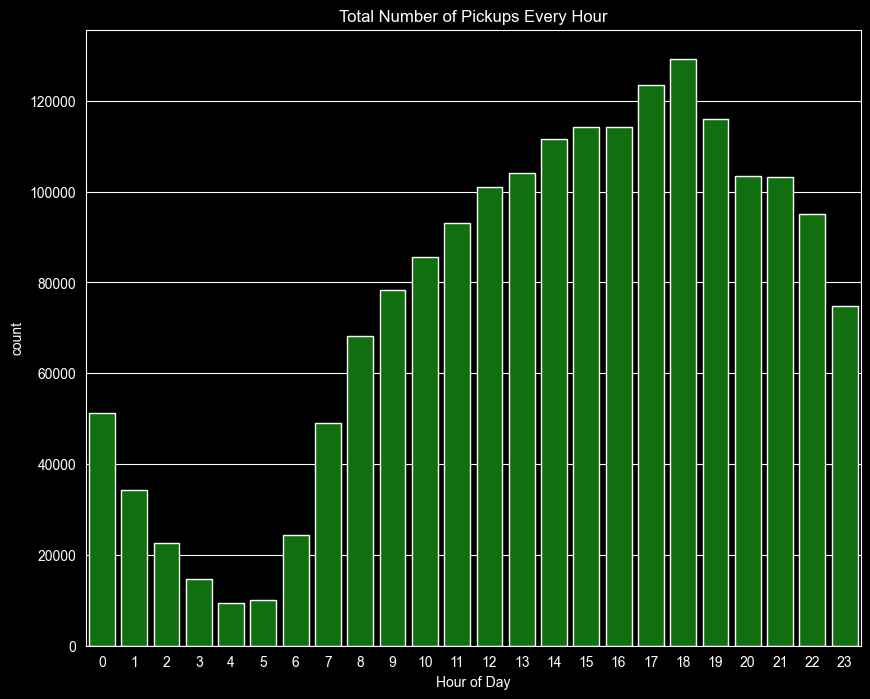

In [52]:
final_data_df['tpep_pickup_datetime_hour'] = final_data_df['tpep_pickup_datetime'].dt.hour
final_data_df['tpep_pickup_datetime_day'] = final_data_df['tpep_pickup_datetime'].dt.day_name()
final_data_df['tpep_pickup_datetime_month'] = final_data_df['tpep_pickup_datetime'].dt.month_name()
final_data_df[['tpep_pickup_datetime_hour','tpep_pickup_datetime_day','tpep_pickup_datetime_month']]

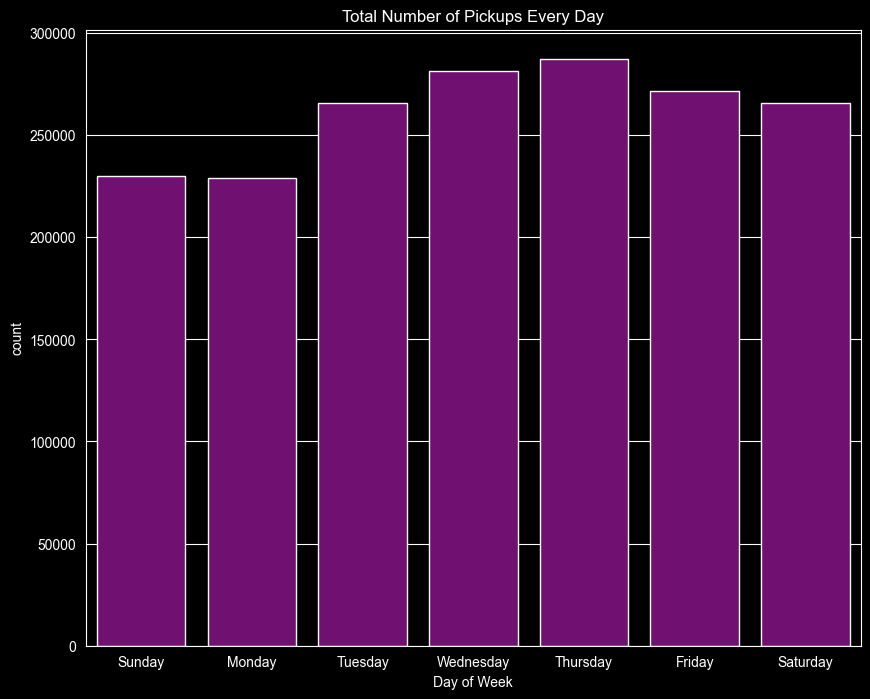

In [53]:
# Find and show the hourly trends in taxi pickups
plt.figure(figsize=(10,8))
sns.countplot(data=final_data_df,x='tpep_pickup_datetime_hour',color='green')
plt.title('Total Number of Pickups Every Hour')
plt.xlabel('Hour of Day')
plt.show()

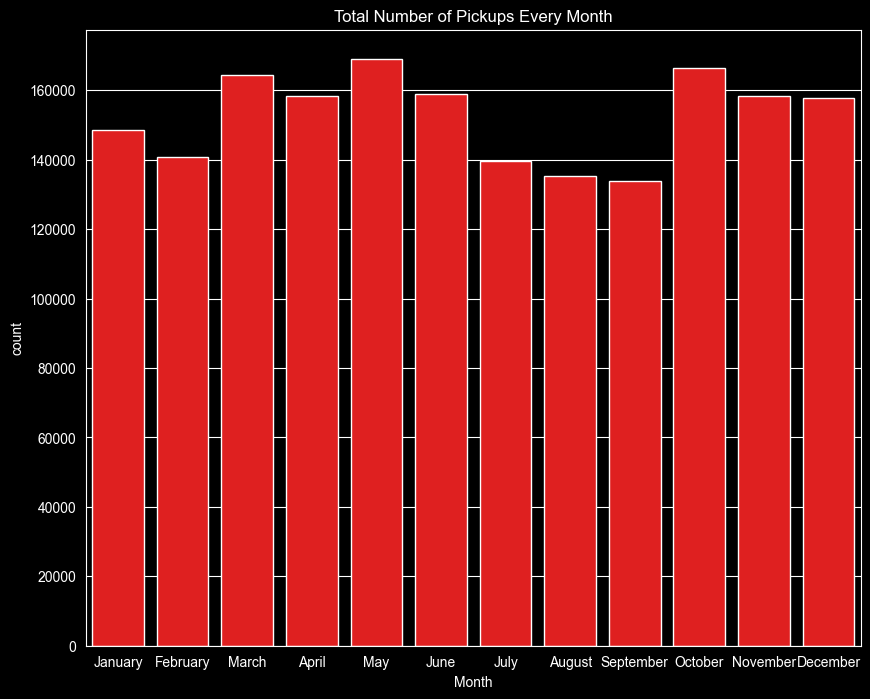

In [54]:
# Find and show the daily trends in taxi pickups (days of the week)
plt.figure(figsize=(10,8))
sns.countplot(data=final_data_df,x='tpep_pickup_datetime_day',color='purple')
plt.title('Total Number of Pickups Every Day')
plt.xlabel('Day of Week')
plt.show()

In [ ]:
# Show the monthly trends in pickups
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
plt.figure(figsize=(10,8))
sns.countplot(data=final_data_df,x='tpep_pickup_datetime_month',color='red',order=month_order)
plt.title('Total Number of Pickups Every Month')
plt.xlabel('Month')
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [ ]:
# Analyse the above parameters
financial_cols = ['fare_amount', 'tip_amount', 'total_amount',  'trip_distance']
for col in financial_cols:
    zero_count = (final_data_df[col]==0).sum()
    negative_count = (final_data_df[col]<0).sum()
    print(f"\nColumn: {col}")
    print(f"Zero Count: {zero_count}")
    print(f"Negative Count: {negative_count}")

Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

no it is not beneficial to create a single copy DataFrame by removing all zero values from the above columns and then use it throughout.
Not all zero values indicate bad or invalid data.

tip_amount = 0 is common and legitimate because cash tips are not recorded in the dataset.
trip_distance = 0 can also be valid, as the assignment itself notes that pickup and drop-off may occur within the same taxi zone or the distance may round to zero.
fare_amount = 0 and total_amount = 0 are comparatively rare and are more likely to represent cancelled, no-charge, or otherwise non-revenue trips.

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [ ]:
# Create a df with non-zero entries for the selected parameters.
non_zero_mask = (final_data_df['fare_amount']>0) & (final_data_df['tip_amount']>0) & (final_data_df['total_amount']>0) &  (final_data_df['trip_distance']>0)
non_zero_final_data_df = final_data_df[non_zero_mask].copy()
print(f"Original df with zero financial col values",final_data_df.shape)
print(f"Filtered df with zero financial col values",non_zero_final_data_df.shape)

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

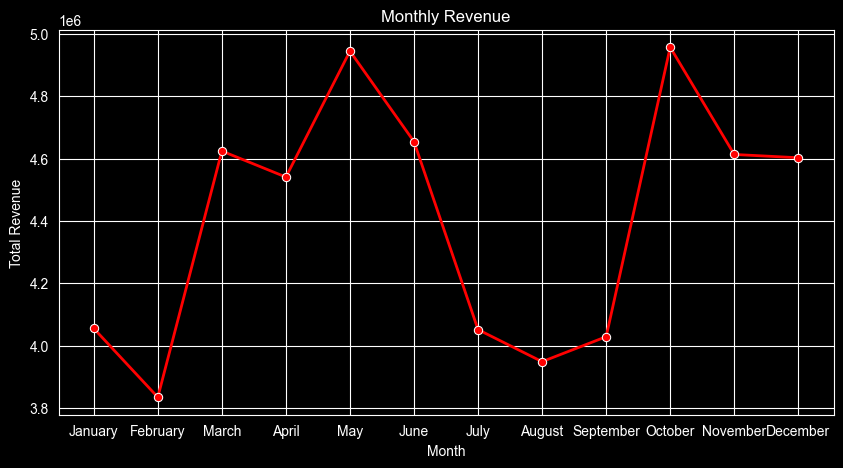

In [120]:
# Group data by month and analyse monthly revenue
monthly_revenue=final_data_df[final_data_df['total_amount']>0].groupby(['tpep_pickup_datetime_month'])['total_amount'].sum().reindex(month_order)
print(monthly_revenue)

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_revenue,color='red',marker='o',linewidth=2)
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.savefig(images_folder_path+'/monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

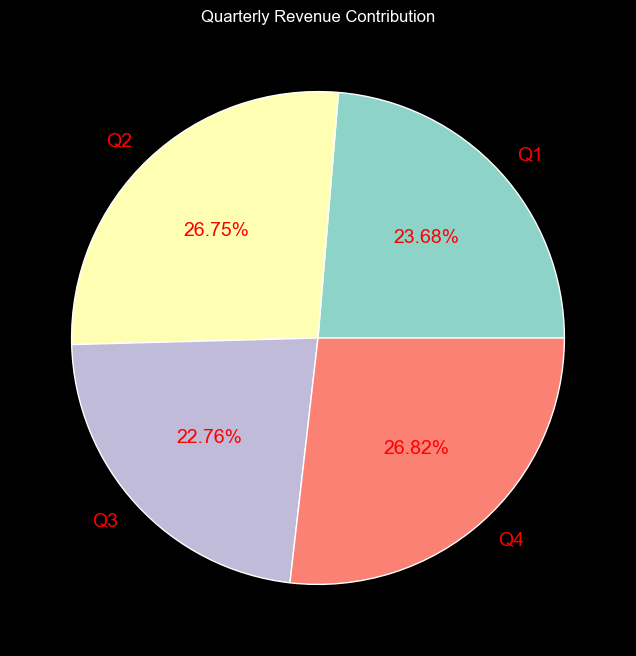

In [60]:
# Calculate proportion of each quarter
quartely_df = final_data_df[final_data_df['total_amount']>0].copy()
quartely_df['pickup_quarter'] = ('Q' + quartely_df['tpep_pickup_datetime'].dt.quarter.astype(str))
quarterly_revenue = quartely_df.groupby(['pickup_quarter'])['total_amount'].sum().sort_index()
#print(quarterly_revenue)
total_revenue = quarterly_revenue.sum()
quarterly_revenue_proportion = (quarterly_revenue/total_revenue)
print(f"---Proportion of Each Quater---\n{quarterly_revenue_proportion}")

In [ ]:
plt.figure(figsize=(10,8))
plt.pie(quarterly_revenue_proportion,labels=quarterly_revenue_proportion.index,autopct='%1.2f%%',textprops={'fontsize':14, 'color':'red'})
plt.title('Quarterly Revenue Contribution')
plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

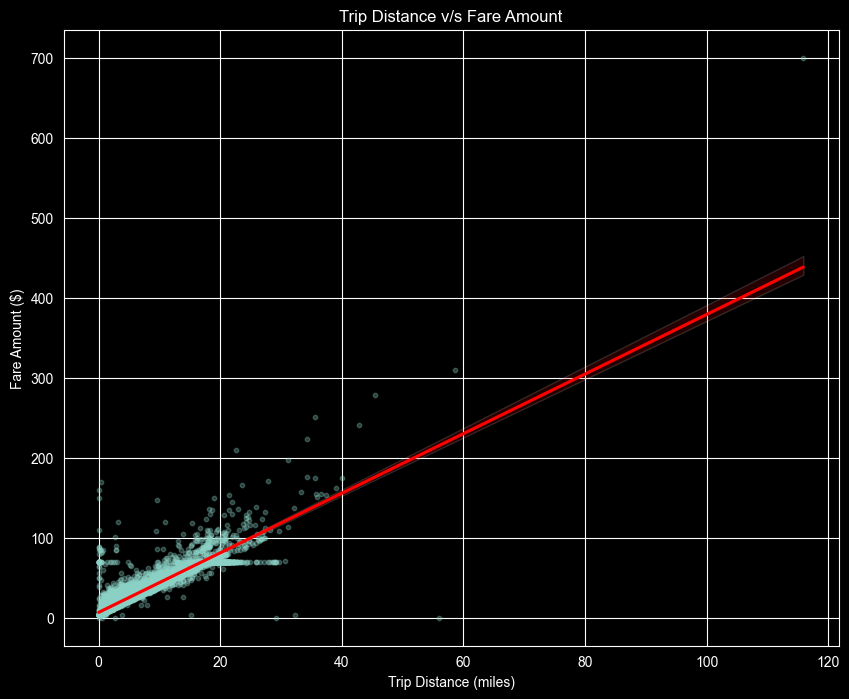

Correlation is: 0.9440


In [62]:
def correlation_plotter(dataframe, x_col, y_col, x_label, y_label,title):
    plt.figure(figsize=(10,8))
    sample_df = dataframe.sample(n=30000,random_state=42)
    sns.regplot(data=sample_df,x=x_col,y=y_col,scatter_kws={'alpha':0.3,'s':10},line_kws={'color':'red'})
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.show()
    correlation = dataframe[x_col].corr(dataframe[y_col])
    print(f"Correlation is: {correlation:.04f}")

In [ ]:
# Show how trip fare is affected by distance
non_zero_fare_df = final_data_df[(final_data_df['trip_distance']>0) & (final_data_df['fare_amount']>=0)].copy()
correlation_plotter(non_zero_fare_df,'trip_distance','fare_amount','Trip Distance (miles)','Fare Amount ($)','Trip Distance v/s Fare Amount')

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

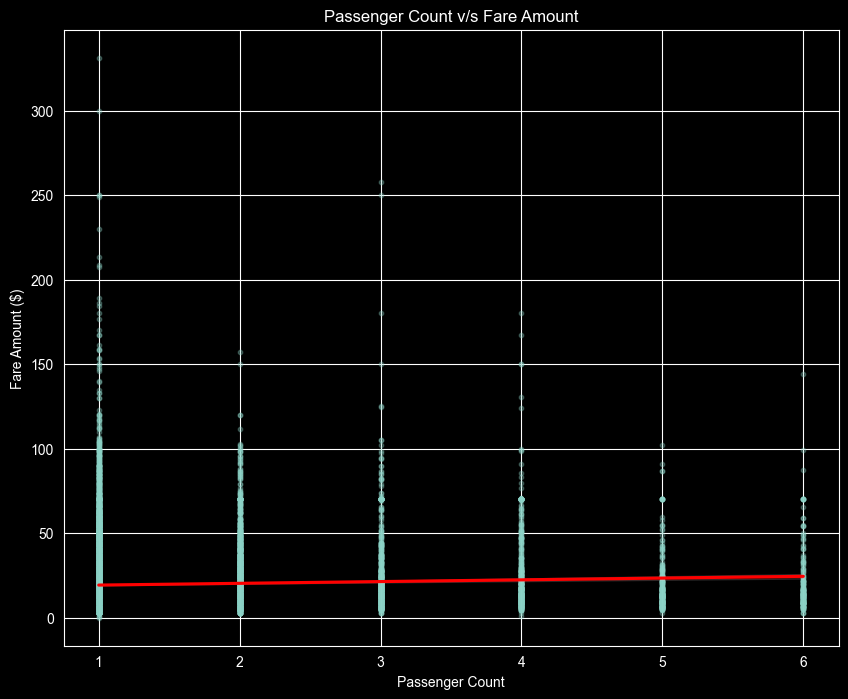

Correlation is: 0.0443


In [64]:
# Show relationship between fare and trip duration
fa_vs_duration_df = final_data_df[final_data_df['fare_amount']>0].copy()
fa_vs_duration_df['trip_duration'] = ((fa_vs_duration_df['tpep_dropoff_datetime']-fa_vs_duration_df['tpep_pickup_datetime']).dt.total_seconds() / 60)
correlation_plotter(fa_vs_duration_df,'trip_duration','fare_amount','Trip Duration (mins)','Fare Amount ($)','Trip Duration v/s Fare Amount')


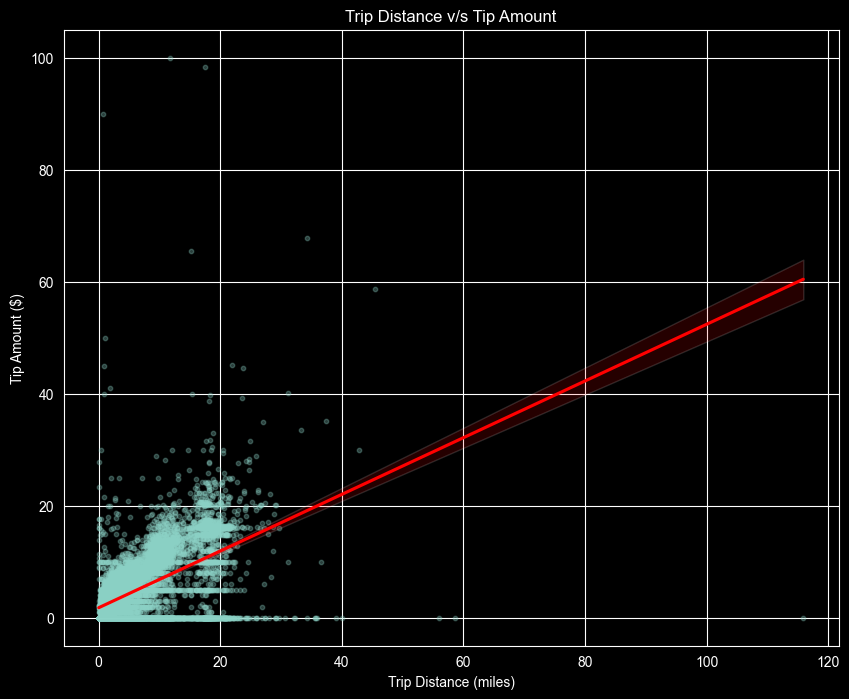

Correlation is: 0.5859


In [65]:
# Show relationship between fare and number of passengers
fare_vs_passengers_df = final_data_df[(final_data_df['fare_amount']>0) & (final_data_df['passenger_count']>0)].copy()
correlation_plotter(fare_vs_passengers_df,'passenger_count','fare_amount','Passenger Count','Fare Amount ($)','Passenger Count v/s Fare Amount')

In [ ]:
# Show relationship between tip and trip distance
tip_vs_distance = final_data_df[final_data_df['trip_distance']>0].copy()
correlation_plotter(tip_vs_distance,'trip_distance','tip_amount','Trip Distance (miles)','Tip Amount ($)',"Trip Distance v/s Tip Amount")

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

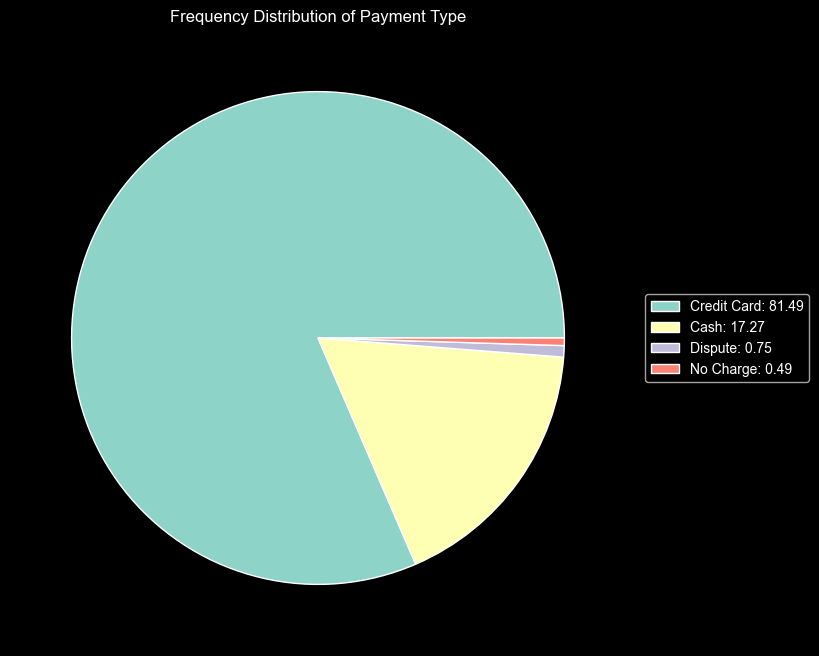

Number of Cash Payment records for 'tip_amount'=0 : 316312


In [67]:
# Analyse the distribution of different payment types (payment_type).
payment_type_map = {1: 'Credit Card',2: 'Cash',3: 'No Charge',4: 'Dispute',5: 'Unknown',6: 'Voided Trip'}
payment_type_named = final_data_df['payment_type'].map(payment_type_map).value_counts()
print(final_data_df['payment_type'].value_counts())

In [68]:
legend_labels = [f"{label}: {value:.2f}" for label,value in zip(payment_type_named.index,(payment_type_named.values/payment_type_named.values.sum())*100)]
plt.figure(figsize=(10,8))
wedges,_=plt.pie(payment_type_named.values)
plt.legend(wedges,legend_labels,loc='center left',bbox_to_anchor=(1.02, 0.5))
plt.title('Frequency Distribution of Payment Type')
plt.show()
print(f"Number of Cash Payment records for 'tip_amount'=0 : {((final_data_df['tip_amount']==0) & (final_data_df['payment_type']==2)).sum()}")

In [ ]:
# we are not filtering on the basis of tip_amount since it is mentioned in the data dictionary that the
# tip_amounts are only recorded with credit card and not for cash payment _type. So if we filter out on the basis of tip_amount>0 we are losing out on several cash payment type.

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [ ]:
# import geopandas as gpd
# Read the shapefile using geopandas
zones = gpd.read_file('/Users/sibtain_raghib/Apps/Spark/Upgrad/Datasets/NYC_Taxi/Datasets and Dictionary/taxi_zones/taxi_zones.shp')
zones.head()

Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

In [ ]:
print(zones.info())
zones.plot(edgecolor='red',figsize=(10,10),color='yellow')
plt.title("NYC Taxi Zone")
plt.savefig(images_folder_path+'/nyc_taxi_zones.png', dpi=150, bbox_inches='tight')
plt.show()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [73]:
# Merge zones and trip records using locationID and PULocationID
final_data_df = final_data_df.merge(zones,how='left',left_on='PULocationID',right_on='LocationID')

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'tpep_pickup_datetime_hour', 'tpep_pickup_datetime_day',
       'tpep_pickup_datetime_month', 'OBJECTID', 'Shape_Leng', 'Shape_Area',
       'zone', 'LocationID', 'borough', 'geometry'],
      dtype='str')

In [ ]:
final_data_df.columns

**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [75]:
# Group data by location and calculate the number of trips
number_of_trips_by_location = final_data_df.groupby('LocationID')['LocationID'].count().reset_index(name='trip_count')
print(f"---Total Number Of Trips Originating from a Zone----\n{number_of_trips_by_location.sort_values('trip_count',ascending=False)}")

Locations not found in trip records:-
[30, 57, 99, 103, 104, 105, 110, 176, 245]


In [ ]:
existing = set(number_of_trips_by_location['LocationID'].astype(int))
not_found = sorted(set(range(1, 264)) - existing)
print(f"Locations not found in trip records:-\n{not_found}")

**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [77]:
# Merge trip counts back to the zones GeoDataFrame
zones = zones.merge(number_of_trips_by_location,how='left',on='LocationID')

---Trip Count Against Each Zone---
     LocationID                   zone  trip_count
131         132            JFK Airport     96815.0
236         237  Upper East Side South     86903.0
160         161         Midtown Center     85943.0
235         236  Upper East Side North     77514.0
161         162           Midtown East     65632.0


In [ ]:
print(f"---Trip Count Against Each Zone---\n{zones[['LocationID', 'zone', 'trip_count']].sort_values(by='trip_count',ascending=False).head()}")

The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

In [79]:
# Define figure and axis
fig,ax = plt.subplots(1,1,figsize=(12,10))
# Plot the map and display it
zones.plot(column='trip_count',ax=ax,legend=True,edgecolor='red',linewidth=0.5,legend_kwds={'label':'Number of Taxi Pickups','orientation':'horizontal'},cmap='Oranges')
ax.set_title('Number of Taxi Pickups By Pickup Zone',fontsize=14)
plt.savefig(images_folder_path+'/number_of_pickups_by_zone.png', dpi=150, bbox_inches='tight')
plt.show()


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
114,115,0.116169,0.000373,Grymes Hill/Clifton,115,Staten Island,"POLYGON ((961850.466 167915.309, 961831.926 16...",1.0
83,84,0.233624,0.002074,Eltingville/Annadale/Prince's Bay,84,Staten Island,"POLYGON ((939754.454 131548.91, 939802.804 131...",1.0
220,221,0.166218,0.000890,Stapleton,221,Staten Island,"POLYGON ((963349.728 171627.581, 963397.759 17...",1.0
26,27,0.202509,0.001341,Breezy Point/Fort Tilden/Riis Beach,27,Queens,"POLYGON ((1021692.969 147138.664, 1021883.624 ...",1.0
171,172,0.118476,0.000658,New Dorp/Midland Beach,172,Staten Island,"POLYGON ((960204.812 146820.751, 960103.437 14...",1.0
...,...,...,...,...,...,...,...,...
103,104,0.021221,0.000012,Governor's Island/Ellis Island/Liberty Island,103,Manhattan,"POLYGON ((973172.666 194632.348, 973310.63 194...",NaN
104,105,0.077425,0.000369,Governor's Island/Ellis Island/Liberty Island,103,Manhattan,"POLYGON ((979605.759 191880.575, 979978.435 19...",NaN
109,110,0.103946,0.000526,Great Kills Park,110,Staten Island,"POLYGON ((951420.092 139894.411, 951856.209 13...",NaN
175,176,0.151995,0.000658,Oakwood,176,Staten Island,"POLYGON ((950393.94 148827.195, 950393.983 148...",NaN


In [ ]:
# can you try displaying the zones DF sorted by the number of trips?
zones.sort_values('trip_count',ascending=True)[zones.columns]

Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


The exploratory data analysis reveals clear temporal, financial, and geographical patterns in NYC taxi operations. Taxi demand peaks during the evening rush hour (6 PM), is highest on Thursdays, and reaches its maximum monthly volume in May, while revenue peaks in October. Revenue remains relatively stable throughout the year, with Q4 contributing the largest share (26.82%) and Q3 the smallest (22.76%).

Among the variables analyzed, trip distance is by far the strongest predictor of fare amount, exhibiting a very strong positive correlation (0.9436). In contrast, trip duration shows only a weak relationship with fare, and passenger count has virtually no effect, confirming that taxi pricing is primarily distance-based rather than occupancy-based. Tip amount demonstrates a moderate positive relationship with trip distance, reflecting that longer trips generally receive higher tips, although tipping behavior is influenced by additional customer-specific factors.

Finally, the geographical analysis indicates that taxi activity is highly concentrated within a limited number of pickup zones, reflecting the concentration of commercial activity, transportation hubs, and major travel destinations within New York City. Overall, these findings provide valuable insights into travel demand, revenue generation, customer behavior, and spatial trip distribution, which can support operational planning and resource allocation for taxi services.

#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [ ]:
# Find routes which have the slowest speeds at different times of the day
final_data_df['trip_duration'] = (final_data_df['tpep_dropoff_datetime'] - final_data_df['tpep_pickup_datetime']).dt.total_seconds() / 3600
route_speed_groups = (final_data_df[(final_data_df['trip_duration']>0) & (final_data_df['trip_distance']>0)].groupby(['PULocationID','DOLocationID','tpep_pickup_datetime_hour'])
                      .agg(avg_distance=('trip_distance','mean'),
                           avg_trip_duration=('trip_duration','mean'))).reset_index()
route_speed_groups['avg_speed_per_route'] = (route_speed_groups['avg_distance']/route_speed_groups['avg_trip_duration'])
print(f"---Average Speed of Routes----\n{route_speed_groups[['PULocationID','DOLocationID','avg_speed_per_route']].sort_values(by='avg_speed_per_route',ascending=True)}")

How does identifying high-traffic, high-demand routes help us?

this data can help taxi operators, fleet managers, and city planners to make better decisions with respect to :-
1. driver allocation - high demand routes indicate areas where passengers  will mostly likely hail cabs. Taxi companies can allocate more drivers/vehicles in these areas during peak hours, thereby reducing passenger wait times and increasing driver utilization.
2. customer satisfaction - shorter pickup times and more reliable service improves customer satisfaction.
3. dynamic pricing - based on busy routes and peak hours surge pricing can be applied and justified as well.

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

In [ ]:
# Visualise the number of trips per hour and find the busiest hour
busiest_hour_df = final_data_df.groupby('tpep_pickup_datetime_hour').size().reset_index(name='trip_count')
print(busiest_hour_df.sort_values(by='trip_count',ascending=False))

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [ ]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.05
busiest_hour_df['scaled_trip_count'] = (busiest_hour_df['trip_count']/sample_fraction)
print(busiest_hour_df.sort_values(by='scaled_trip_count',ascending=False).head())

**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

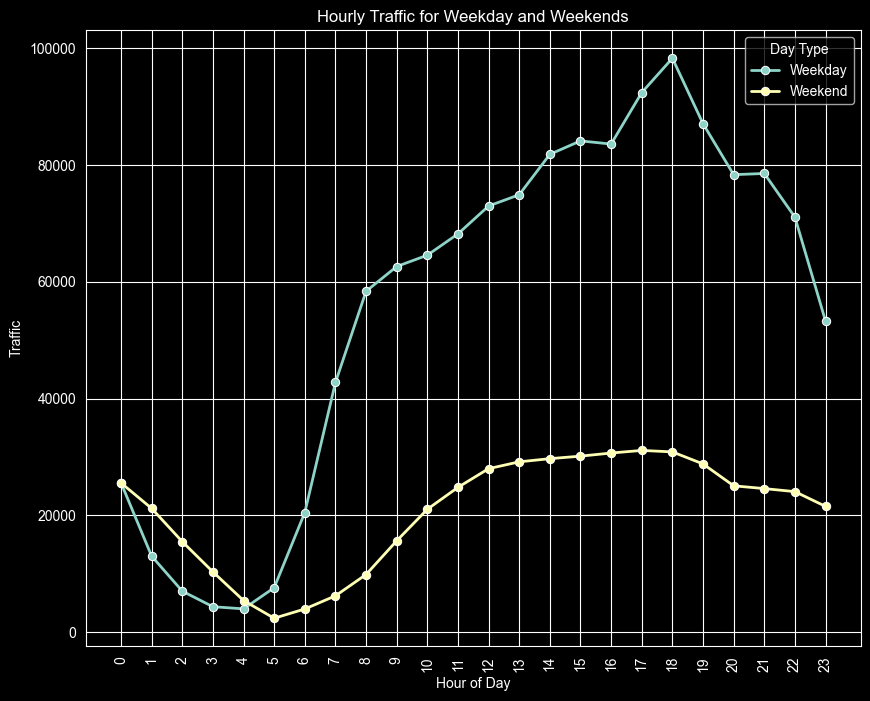

In [84]:
# Compare traffic trends for the week days and weekends
day_type_hourly_trend = (final_data_df.assign(day_type=np.where(final_data_df['tpep_pickup_datetime_day'].isin(['Saturday','Sunday']),'Weekend','Weekday'))).groupby(['day_type','tpep_pickup_datetime_hour']).size().reset_index(name='traffic_by_day_type')
print(f"----Comparison of Hourly Traffic for Weekday and Weekends---- \n{day_type_hourly_trend}")

In [ ]:
plt.figure(figsize=(10,8))
sns.lineplot(data=day_type_hourly_trend,x='tpep_pickup_datetime_hour',y='traffic_by_day_type',hue='day_type',linewidth=2,marker='o')
plt.xticks(range(24),rotation=90)
plt.xlabel('Hour of Day')
plt.ylabel('Traffic')
plt.title('Hourly Traffic for Weekday and Weekends')
plt.legend(title='Day Type')
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

Weekdays:-
1. Traffic drops sharply after midnight with the quietest hours between 3-4 AM
2. Traffic increase from 5AM onwards maybe due to the morning commute
3. Demand peaks at 6PM reflecting the peak rush hours.
4. After 6PM the traffic gradually declines as the remaining day progresses.


Weekends:-
1. Traffic is lower post midnight but still is higher than Weekdays
2. Traffic increase later in the day in comparison to weekdays, mostly around 6-7AM.
3. Demand remains constant almost throughout the afternoon and evening.
4. Weekend demand peaks at 6PM but is much lower than weekdays.


Identifying busy and quiet hours will provide valuable operational and business insights:-
1. fleet management - Operators cab allocate more vehicles during peak demand hours and reduce fleet availability during quiet hours. This will also help drivers to get significant rest and prevent over-exhaustion of drivers thus reducing accidents.
2. customer satisfaction - having more taxis available during busy hours decreases passenger wait times and improves customer satisfaction
3. Demand forecasting - historical hourly demand patterns help predict future demand thus enabling better planning during holidays, special events and other variables.
3. dynamic pricing - based on busy routes and peak hours surge pricing can be applied and drivers can be provided with better incentives during peak demand periods.

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [86]:
# Find top 10 pickup and dropoff zones
pickups_by_hour = final_data_df.groupby(['PULocationID','tpep_pickup_datetime_hour']).size().reset_index(name='hourly_pickup_count')
top10_pickup = pickups_by_hour.groupby('PULocationID')['hourly_pickup_count'].mean().reset_index(name='avg_hourly_pickup').sort_values(by='avg_hourly_pickup',ascending=False).head(10)
top10_pickup = top10_pickup.merge(zones[['LocationID','zone']],how='left',left_on='PULocationID',right_on='LocationID')
print(f"---Avg Hourly Pickup---\n{top10_pickup[['PULocationID','avg_hourly_pickup','zone']]}")

---Avg Hourly Dropoff---
   DOLocationID  avg_hourly_dropoff                       zone
0           236         3386.125000      Upper East Side North
1           237         3231.541667      Upper East Side South
2           161         2985.166667             Midtown Center
3           230         2350.083333  Times Sq/Theatre District
4           170         2262.958333                Murray Hill
5           162         2177.083333               Midtown East
6           142         2145.500000        Lincoln Square East
7           239         2135.583333      Upper West Side South
8           141         2018.625000            Lenox Hill West
9            68         1931.458333               East Chelsea


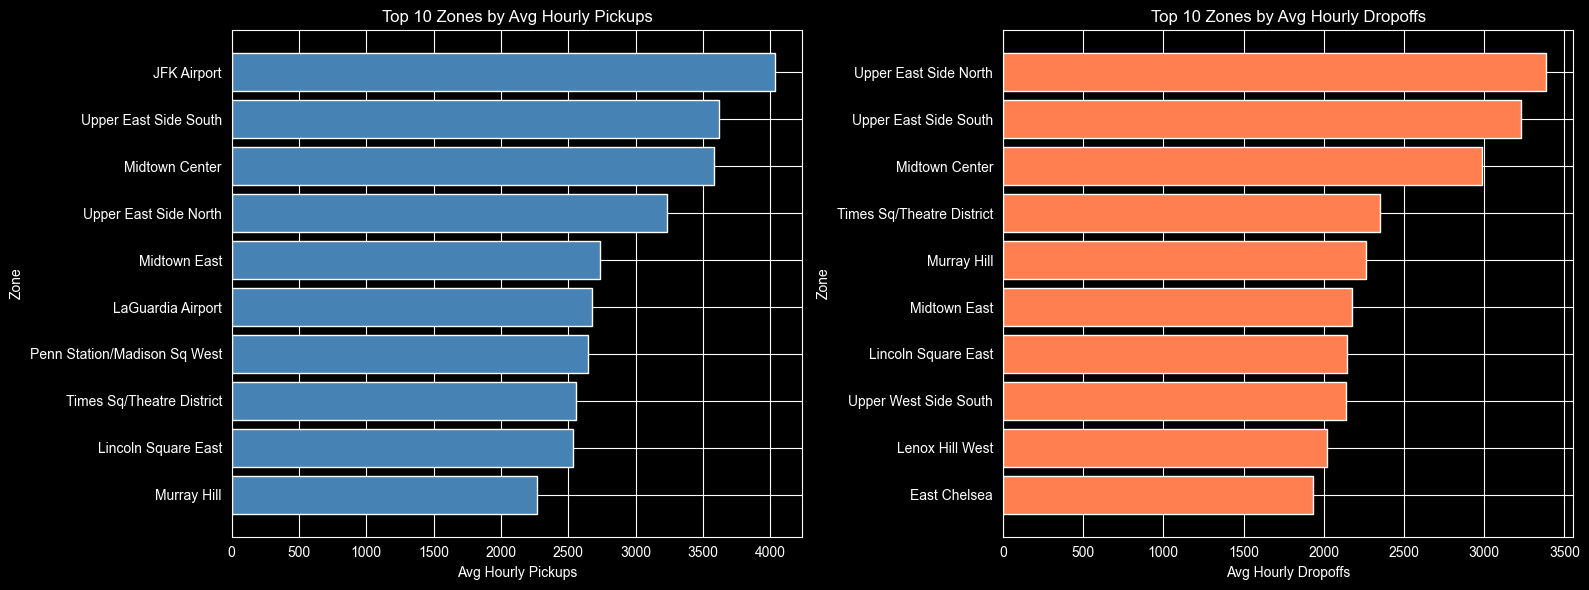

In [126]:
final_data_df['tpep_dropoff_datetime_hour'] = final_data_df['tpep_dropoff_datetime'].dt.hour
dropoff_by_hour = final_data_df.groupby(['DOLocationID','tpep_dropoff_datetime_hour']).size().reset_index(name='hourly_dropoff_count')
top10_dropoff = dropoff_by_hour.groupby('DOLocationID')['hourly_dropoff_count'].mean().reset_index(name='avg_hourly_dropoff').sort_values(by='avg_hourly_dropoff',ascending=False).head(10)
top10_dropoff = top10_dropoff.merge(zones[['LocationID','zone']],how='left',left_on='DOLocationID',right_on='LocationID')
print(f"---Avg Hourly Dropoff---\n{top10_dropoff[['DOLocationID','avg_hourly_dropoff','zone']]}")

In [ ]:
fig,axes=plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(top10_pickup['zone'],top10_pickup['avg_hourly_pickup'],color='steelblue')
axes[0].set_title('Top 10 Zones by Avg Hourly Pickups')
axes[0].set_xlabel('Avg Hourly Pickups')
axes[0].set_ylabel('Zone')
axes[0].invert_yaxis()

axes[1].barh(top10_dropoff['zone'], top10_dropoff['avg_hourly_dropoff'],color='coral')
axes[1].set_title('Top 10 Zones by Avg Hourly Dropoffs')
axes[1].set_xlabel('Avg Hourly Dropoffs')
axes[1].set_ylabel('Zone')
axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig(images_folder_path+'/avg_hourly_pu_do.png', dpi=150, bbox_inches='tight')
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [ ]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
pickups_by_zone = final_data_df.groupby(['PULocationID']).size().reset_index(name='pickup_count')
dropoffs_by_zone = final_data_df.groupby(['DOLocationID']).size().reset_index(name='dropoff_count')
pickup_dropoff = pickups_by_zone.merge(dropoffs_by_zone,how='inner',left_on='PULocationID',right_on='DOLocationID')
pickup_dropoff = pickup_dropoff.merge(zones,how='left',left_on='PULocationID',right_on='LocationID')[['LocationID','zone','pickup_count','dropoff_count']]
pickup_dropoff['PU/DO_Ratio'] = pickup_dropoff['pickup_count']/pickup_dropoff['dropoff_count']
print("---Lowest 10 Pickup-dropoff Ratio---")
print(pickup_dropoff[['LocationID','zone','PU/DO_Ratio']].sort_values(by='PU/DO_Ratio',ascending=True).head(10).reset_index(drop=True))
print("---Highest 10 Pickup-dropoff Ratio---")
print(pickup_dropoff[['LocationID','zone','PU/DO_Ratio']].sort_values(by='PU/DO_Ratio',ascending=False).head(10).reset_index(drop=True))

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [90]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
night_hours = [23,0,1,2,3,4,5]
night_hours_pickup=final_data_df.loc[(final_data_df['tpep_pickup_datetime_hour'].isin(night_hours))]
night_hours_pickup = night_hours_pickup.groupby(['PULocationID']).size().reset_index(name='night_hours_pu_count').sort_values(by='night_hours_pu_count',ascending=False).head(10)
night_hours_pickup = night_hours_pickup.merge(zones,how='left',left_on='PULocationID',right_on='LocationID')
print("---Highest 10 Night Hours Pickup---")
print(night_hours_pickup[['PULocationID','night_hours_pu_count','zone']])

---Highest 10 Night Hours Dropoff---
   DOLocationID  night_hours_do_count                       zone
0            79                  8876               East Village
1            48                  7448               Clinton East
2           170                  6694                Murray Hill
3            68                  6266               East Chelsea
4           107                  6151                   Gramercy
5           141                  5787            Lenox Hill West
6           263                  5473             Yorkville West
7           249                  5321               West Village
8           230                  5156  Times Sq/Theatre District
9           239                  4881      Upper West Side South


In [ ]:
night_hours = [23,0,1,2,3,4,5]
night_hours_dropoff=final_data_df.loc[(final_data_df['tpep_dropoff_datetime_hour'].isin(night_hours))]
night_hours_dropoff = night_hours_dropoff.groupby(['DOLocationID']).size().reset_index(name='night_hours_do_count').sort_values(by='night_hours_do_count',ascending=False).head(10)
night_hours_dropoff = night_hours_dropoff.merge(zones,how='left',left_on='DOLocationID',right_on='LocationID')
print("---Highest 10 Night Hours Dropoff---")
print(night_hours_dropoff[['DOLocationID','night_hours_do_count','zone']])

Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [ ]:
# Filter for night hours (11 PM to 5 AM)
night_day_revenue_split = (final_data_df
                           .assign(time_of_day = np.where(final_data_df['tpep_pickup_datetime_hour'].isin(night_hours),'Night','Day'))
                           .groupby(['time_of_day'])['total_amount']
                           .agg(total_revenue='sum',
                                avg_revenue='mean',
                                trip_count='count').reset_index())
night_day_revenue_split['revenue_share_%'] = (night_day_revenue_split['total_revenue']/night_day_revenue_split['total_revenue'].sum())*100
print(f"---Night-Day Revenue Split---\n{night_day_revenue_split}")

##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

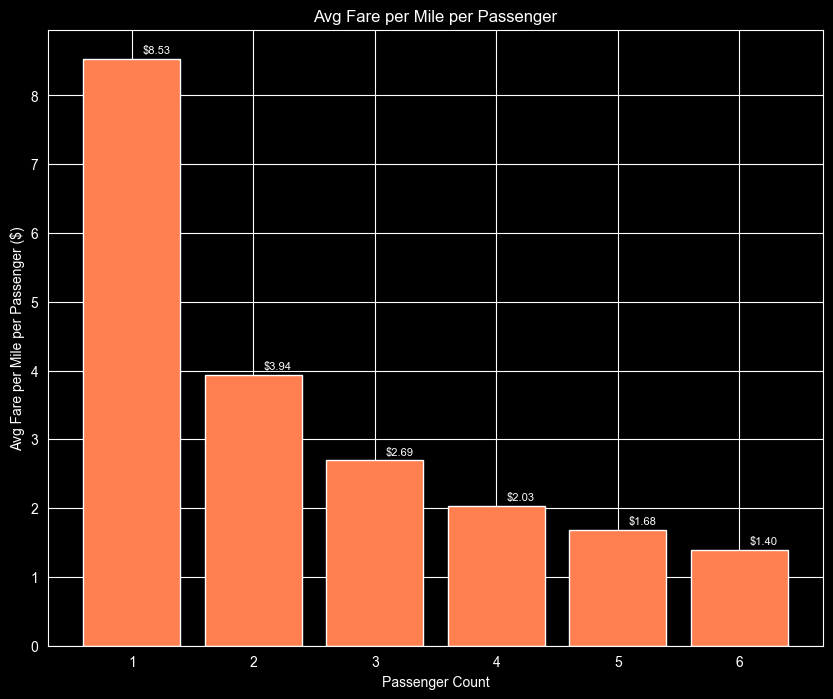

In [93]:
# Analyse the fare per mile per passenger for different passenger counts
fare_per_mile_pax = (final_data_df
                    .groupby(['passenger_count'])[['trip_distance','total_amount']]
                    .agg(total_fare=('total_amount','sum'),
                         total_distance=('trip_distance','sum'))
                    .reset_index()
                 )
fare_per_mile_pax['avg_fare_per_mile'] = fare_per_mile_pax['total_fare']/fare_per_mile_pax['total_distance']
fare_per_mile_pax['avg_fare_per_mile_per_pax'] = fare_per_mile_pax['avg_fare_per_mile']/fare_per_mile_pax['passenger_count']
print(f"---Average Fare per Mile Per Passenger---\n{fare_per_mile_pax[['passenger_count','avg_fare_per_mile','avg_fare_per_mile_per_pax']].sort_values(by='avg_fare_per_mile_per_pax',ascending=False)}")

In [ ]:
plt.figure(figsize=(10, 8))
plt.bar(fare_per_mile_pax['passenger_count'].astype(int),fare_per_mile_pax['avg_fare_per_mile_per_pax'],color='coral')
plt.title('Avg Fare per Mile per Passenger')
plt.xlabel('Passenger Count')
plt.ylabel('Avg Fare per Mile per Passenger ($)')
plt.xticks(fare_per_mile_pax['passenger_count'].astype(int))
for i, v in enumerate(fare_per_mile_pax['avg_fare_per_mile_per_pax']):
    plt.text(i+1.2, v+0.08, f'${v:.2f}',ha='center', fontsize=8)
plt.show()

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [95]:
# Compare the average fare per mile for different days and for different times of the day
fare_per_mile_hour = (final_data_df
                    .groupby(['tpep_pickup_datetime_hour'])[['trip_distance','total_amount']]
                    .agg(total_fare=('total_amount','sum'),
                         total_distance=('trip_distance','sum'))
                    .reset_index()
                 )
fare_per_mile_hour['avg_fare_per_mile'] = fare_per_mile_hour['total_fare']/fare_per_mile_hour['total_distance']
print(f"---Average Fare per Mile For Different Hours---\n{fare_per_mile_hour.sort_values(by='avg_fare_per_mile',ascending=False)}")

---Average Fare per Mile For Different Days---
  tpep_pickup_datetime_day  total_fare  total_distance  avg_fare_per_mile
6                Wednesday  8132315.79       925453.42           8.787385
4                 Thursday  8392216.46       959499.27           8.746454
5                  Tuesday  7661363.03       887876.15           8.628865
0                   Friday  7840932.41       916638.51           8.554007
2                 Saturday  7167700.95       860890.19           8.325918
1                   Monday  6841261.95       859076.66           7.963506
3                   Sunday  6825528.57       899508.96           7.588061


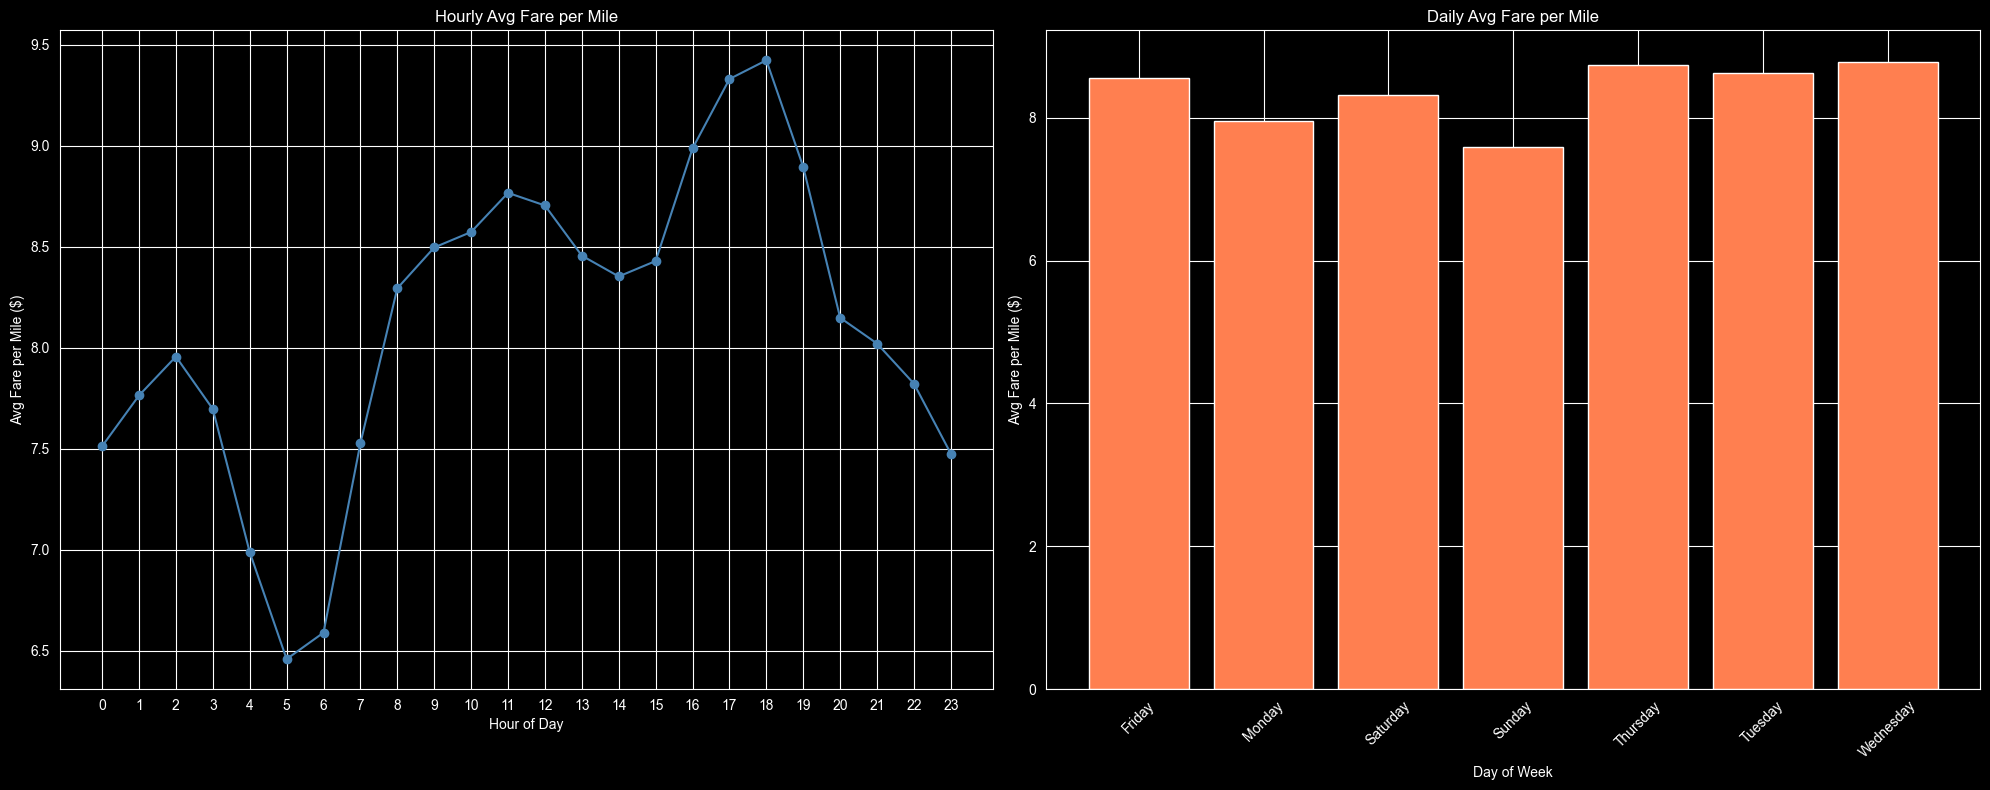

In [96]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fare_per_mile_day = (final_data_df
                    .groupby(['tpep_pickup_datetime_day'])[['trip_distance','total_amount']]
                    .agg(total_fare=('total_amount','sum'),
                         total_distance=('trip_distance','sum'))
                    .reset_index()
                 )
fare_per_mile_day['tpep_pickup_datetime_day'] = pd.Categorical(fare_per_mile_day['tpep_pickup_datetime_day'],categories=day_order,ordered=True)
fare_per_mile_day['avg_fare_per_mile'] = fare_per_mile_day['total_fare']/fare_per_mile_day['total_distance']
print(f"---Average Fare per Mile For Different Days---\n{fare_per_mile_day.sort_values('avg_fare_per_mile',ascending=False)}")

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(20,8))
ax[0].plot(fare_per_mile_hour['tpep_pickup_datetime_hour'],fare_per_mile_hour['avg_fare_per_mile'],marker='o',color='steelblue')
ax[0].set_title('Hourly Avg Fare per Mile')
ax[0].set_xlabel('Hour of Day')
ax[0].set_ylabel('Avg Fare per Mile ($)')
ax[0].set_xticks(range(24))

ax[1].bar(fare_per_mile_day['tpep_pickup_datetime_day'],fare_per_mile_day['avg_fare_per_mile'],color='coral')
ax[1].set_title('Daily Avg Fare per Mile')
ax[1].set_xlabel('Day of Week')
ax[1].set_ylabel('Avg Fare per Mile ($)')
ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

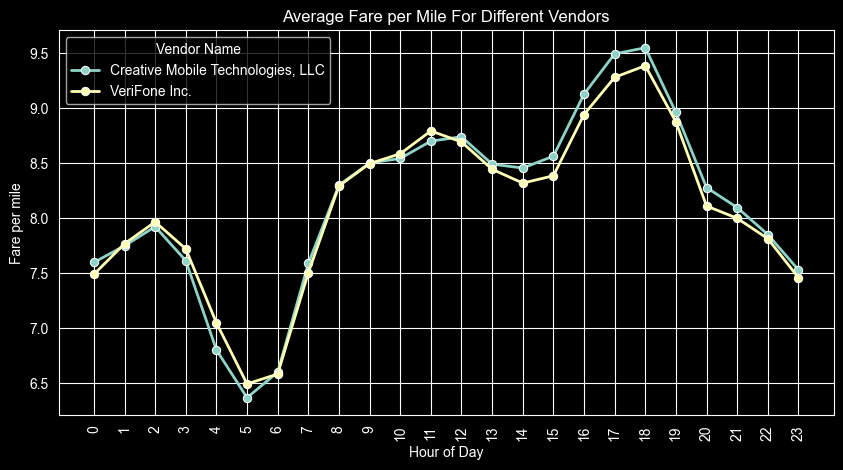

In [127]:
# Compare fare per mile for different vendors
fare_per_mile_vendor = (final_data_df
                    .groupby(['VendorID','tpep_pickup_datetime_hour'])[['trip_distance','total_amount']]
                    .agg(total_fare=('total_amount','sum'),
                         total_distance=('trip_distance','sum'))
                    .reset_index()
                 )
fare_per_mile_vendor['Vendor'] = fare_per_mile_vendor['VendorID'].map({1:'Creative Mobile Technologies, LLC',2:'VeriFone Inc.'})
fare_per_mile_vendor['avg_fare_per_mile'] = fare_per_mile_vendor['total_fare']/fare_per_mile_vendor['total_distance']
print(f"---Average Fare per Mile For Different Vendors---\n{fare_per_mile_vendor[['VendorID','Vendor','tpep_pickup_datetime_hour','avg_fare_per_mile']]}")

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(data=fare_per_mile_vendor,x='tpep_pickup_datetime_hour',y='avg_fare_per_mile',hue='Vendor',linewidth=2,marker='o')
plt.xticks(range(24),rotation=90)
plt.xlabel('Hour of Day')
plt.ylabel('Fare per mile')
plt.title('Average Fare per Mile For Different Vendors')
plt.legend(title='Vendor Name')
plt.savefig(images_folder_path+'/avg_fare_per_mile_vendors.png', dpi=150, bbox_inches='tight')
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [100]:
# Defining distance tiers
def distance_tier_util(distance):
    if distance<=2:
        return 'Short (0-2 miles)'
    elif distance <= 5:
        return 'Medium (2-5 miles)'
    else :
        return 'Long (5+ miles)'


final_data_df['distance_tier'] = final_data_df['trip_distance'].apply(distance_tier_util)
tier_df = final_data_df[final_data_df['trip_distance']>0].copy()

Fare/Mile for different Vendors per Distance Tier
   VendorID                             Vendor       distance_tier  \
0         1  Creative Mobile Technologies, LLC     Long (5+ miles)   
1         1  Creative Mobile Technologies, LLC  Medium (2-5 miles)   
2         1  Creative Mobile Technologies, LLC   Short (0-2 miles)   
3         2                      VeriFone Inc.     Long (5+ miles)   
4         2                      VeriFone Inc.  Medium (2-5 miles)   
5         2                      VeriFone Inc.   Short (0-2 miles)   

   avg_fare_per_mile  
0           5.678981  
1           8.927643  
2          14.621010  
3           5.833616  
4           9.224554  
5          14.921998  


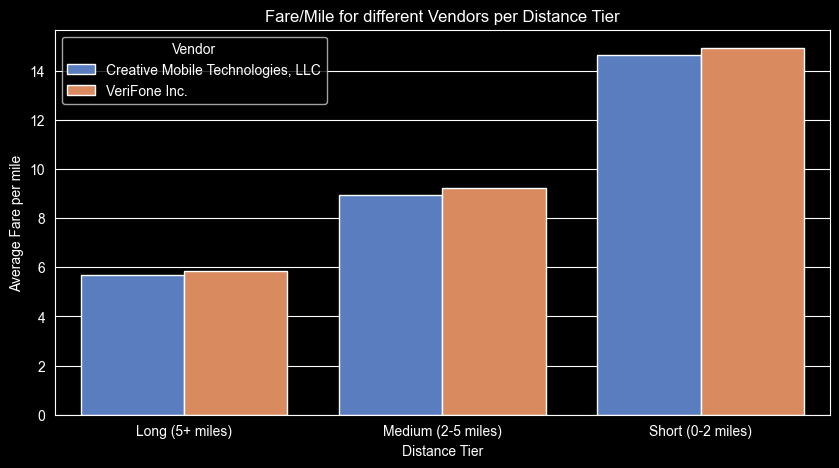

In [101]:
vendor_distance_tier = (tier_df
                .groupby(['VendorID','distance_tier'])[['trip_distance','total_amount']]
                .agg(total_fare=('total_amount','sum'),
                    total_distance=('trip_distance','sum'))
                .reset_index())
vendor_distance_tier['Vendor'] = vendor_distance_tier['VendorID'].map({1:'Creative Mobile Technologies, LLC',2:'VeriFone Inc.'})
vendor_distance_tier['avg_fare_per_mile'] = vendor_distance_tier['total_fare']/vendor_distance_tier['total_distance']
print(f"Fare/Mile for different Vendors per Distance Tier\n{vendor_distance_tier[['VendorID','Vendor','distance_tier','avg_fare_per_mile']]}")

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(data=vendor_distance_tier,x='distance_tier',y='avg_fare_per_mile',hue='Vendor',palette='muted')
plt.title("Fare/Mile for different Vendors per Distance Tier")
plt.xlabel('Distance Tier')
plt.ylabel('Average Fare per mile')
plt.show()

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [103]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
tip_df = final_data_df[(final_data_df['fare_amount']>0) & (final_data_df['payment_type']==1)].copy()
tip_df['tip_percentage'] = (tip_df['tip_amount']/tip_df['fare_amount'])*100
tip_by_distance = (tip_df
                   .groupby(['distance_tier'])[['tip_percentage']]
                   .agg(avg_tip_pct=('tip_percentage','mean'))
                   .reset_index())
distance_tier_order = ['Short (0-2 miles)','Medium (2-5 miles)','Long (5+ miles)']
tip_by_distance['distance_tier'] = pd.Categorical(tip_by_distance['distance_tier'],categories=distance_tier_order,ordered=True)
print(f"---Tips by Distance---\n{tip_by_distance.sort_values('avg_tip_pct')}")

---Tips by Passenger Count---
   passenger_count  avg_tip_pct
3              4.0    24.148357
2              3.0    24.445068
4              5.0    25.161203
5              6.0    25.197763
1              2.0    25.660754
0              1.0    26.668056


In [104]:
tip_by_pax = (tip_df
                   .groupby(['passenger_count'])[['tip_percentage']]
                   .agg(avg_tip_pct=('tip_percentage','mean'))
                   .reset_index())
print(f"---Tips by Passenger Count---\n{tip_by_pax.sort_values('avg_tip_pct')}")

---Tips by PU Time---
    tpep_pickup_datetime_hour  avg_tip_pct
0                          15    31.959123
1                           0    31.694641
2                          17    29.718640
3                          23    28.669568
4                          18    26.708428
5                          19    26.641188
6                          14    26.584432
7                          16    26.102060
8                          13    25.603162
9                          20    25.595578
10                         21    25.561947
11                          3    25.149284
12                          1    25.104713
13                         22    25.063395
14                          4    24.844263
15                          2    24.642897
16                         10    24.511506
17                         11    24.459891
18                         12    24.441795
19                          9    24.282745
20                          8    23.886947
21                          7   

In [ ]:
tip_by_pickup_time = (tip_df
                   .groupby(['tpep_pickup_datetime_hour'])[['tip_percentage']]
                   .agg(avg_tip_pct=('tip_percentage','mean'))
                   .reset_index())
print(f"---Tips by PU Time---\n{tip_by_pickup_time.sort_values('avg_tip_pct',ascending=False).reset_index(drop=True)}")

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [ ]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [107]:
# See how passenger count varies across hours and days
pax_count_by_hour = (final_data_df
                     .groupby('tpep_pickup_datetime_hour')['passenger_count']
                     .mean()
                     .reset_index(name='avg_pax_count'))

print(f"---Average Passenger Count Across Hours---\n{pax_count_by_hour.sort_values(by='avg_pax_count',ascending=False).reset_index(drop=True)}")

---Average Passenger Count Across Days---
  tpep_pickup_datetime_day  avg_pax_count
0                   Monday       1.360939
1                  Tuesday       1.332990
2                Wednesday       1.329654
3                 Thursday       1.343042
4                   Friday       1.400152
5                 Saturday       1.479920
6                   Sunday       1.464337


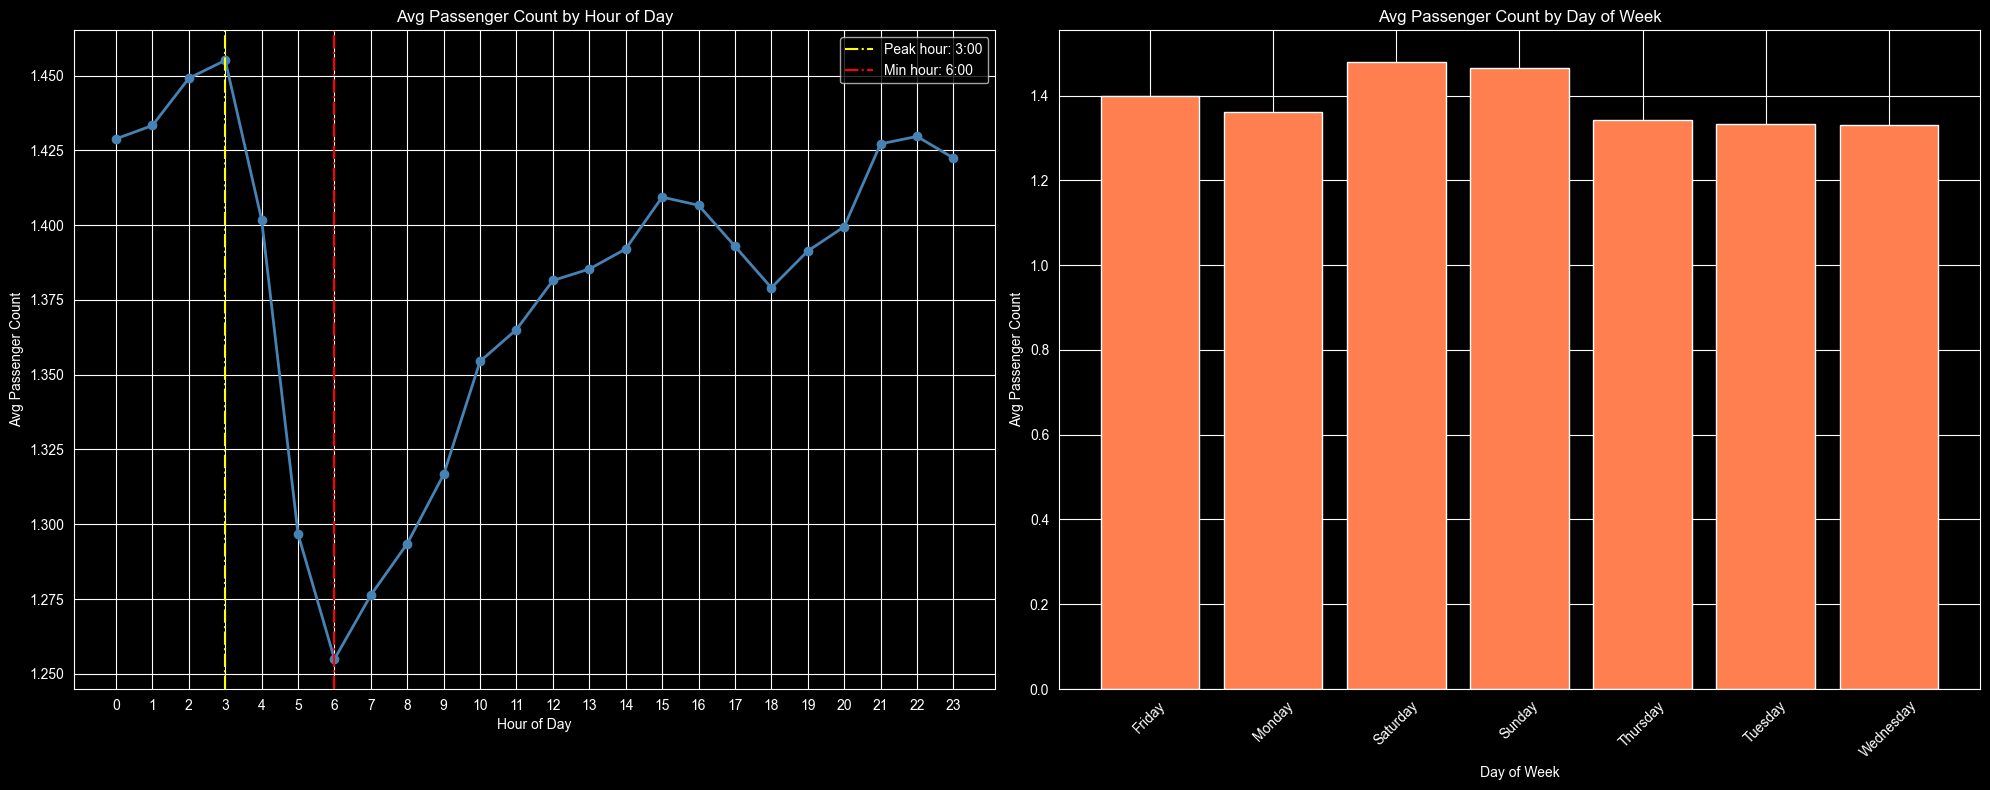

In [128]:
pax_count_by_day = (final_data_df
                     .groupby('tpep_pickup_datetime_day')['passenger_count']
                     .mean()
                     .reset_index(name='avg_pax_count'))
pax_count_by_day['tpep_pickup_datetime_day'] = pd.Categorical(pax_count_by_day['tpep_pickup_datetime_day'],categories=day_order,ordered=True)
print(f"---Average Passenger Count Across Days---\n{pax_count_by_day.sort_values(by='tpep_pickup_datetime_day').reset_index(drop=True)}")

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(20,8))

ax[0].plot(pax_count_by_hour['tpep_pickup_datetime_hour'],pax_count_by_hour['avg_pax_count'],linewidth=2,marker='o',color='steelblue')
ax[0].set_title('Avg Passenger Count by Hour of Day')
ax[0].set_xlabel('Hour of Day')
ax[0].set_ylabel('Avg Passenger Count')
ax[0].set_xticks(range(24))
min_hour = pax_count_by_hour.loc[pax_count_by_hour['avg_pax_count'].idxmin(),'tpep_pickup_datetime_hour']
max_hour = pax_count_by_hour.loc[pax_count_by_hour['avg_pax_count'].idxmax(),'tpep_pickup_datetime_hour']
ax[0].axvline(max_hour, color='yellow',label=f'Peak hour: {max_hour}:00',linestyle='dashdot')
ax[0].axvline(min_hour, color='red',label=f'Min hour: {min_hour}:00',linestyle='dashdot')
ax[0].legend()

ax[1].bar(pax_count_by_day['tpep_pickup_datetime_day'],pax_count_by_day['avg_pax_count'],color='coral')
ax[1].set_title('Avg Passenger Count by Day of Week')
ax[1].set_xlabel('Day of Week')
ax[1].set_ylabel('Avg Passenger Count')
ax[1].tick_params(axis='x', rotation=45)

plt.savefig(images_folder_path+'/avg_pax_count_hour_and_day.png',dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [110]:
# How does passenger count vary across zones
pax_count_by_zones = (final_data_df[final_data_df['passenger_count']>0]
                      .groupby(['LocationID','zone'])['passenger_count']
                      .mean()
                      .reset_index(name='avg_pax_count')
                      .sort_values('avg_pax_count',ascending=False))
print(f"---Average passenger count across each zone---\n{pax_count_by_zones.reset_index(drop=True)}")

In [111]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
zones = zones.merge(pax_count_by_zones,how='left',on='LocationID')

In [112]:
zones.drop(columns=['zone_y','PULocationID'],inplace=True,errors='ignore')
zones = zones.rename(columns={'zone_x':'zone'})

     LocationID                          zone  avg_pax_count  trip_count
5             6       Arrochar/Fort Wadsworth       1.875000        24.0
194         195                      Red Hook       1.800995       201.0
203         204             Rossville/Woodrow       1.800000         5.0
11           12                  Battery Park       1.745432       821.0
177         178           Ocean Parkway South       1.666667        12.0
57           58                  Country Club       1.666667         3.0
0             1                Newark Airport       1.602804       214.0
65           66            DUMBO/Vinegar Hill       1.584582       467.0
260         261            World Trade Center       1.545691      9608.0
193         194               Randalls Island       1.539683        63.0
44           45                     Chinatown       1.535354      2475.0
92           93  Flushing Meadows-Corona Park       1.532300       387.0
33           34            Brooklyn Navy Yard      

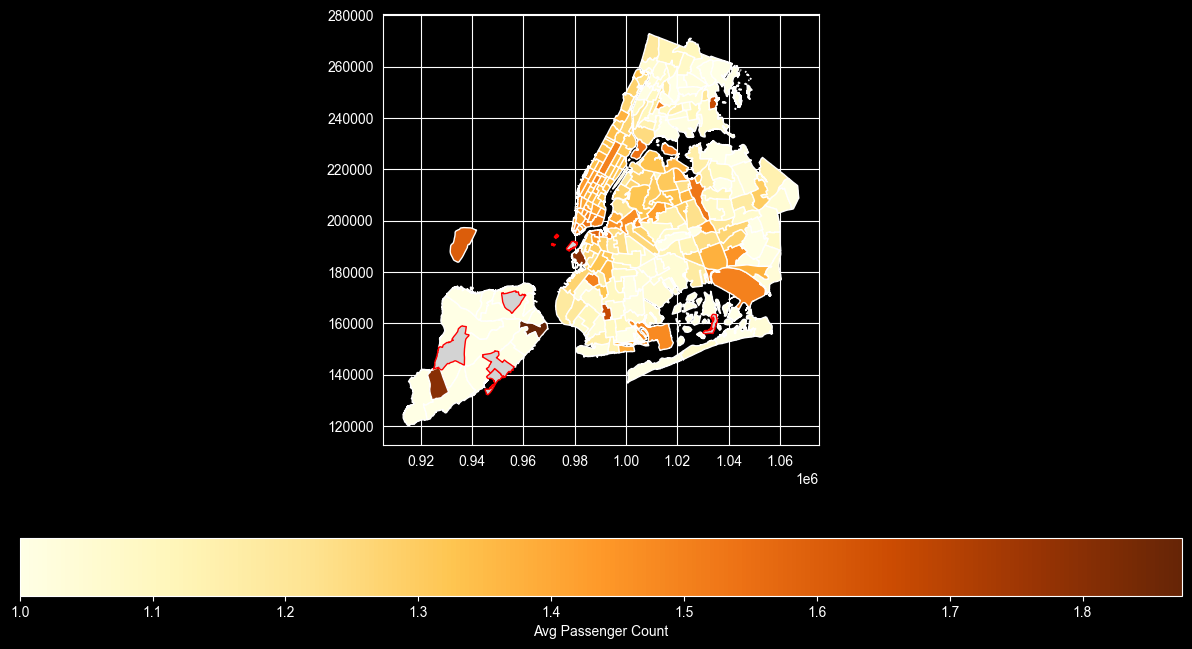

In [129]:
print(zones.sort_values(by='avg_pax_count',ascending=False)[['LocationID','zone','avg_pax_count','trip_count']].head(20))

In [ ]:
fig,ax= plt.subplots(1,1,figsize=(15,8))
zones.plot(column='avg_pax_count'
           ,cmap='YlOrBr'
           ,legend=True
           ,legend_kwds={'label':'Avg Passenger Count','orientation':'horizontal'}
           ,missing_kwds={'color':'lightgrey','label':'No Data','edgecolor':'red'},ax=ax)
plt.savefig(images_folder_path+'/avg_pax_count_across_zones.png',dpi=150, bbox_inches='tight')
plt.show()

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

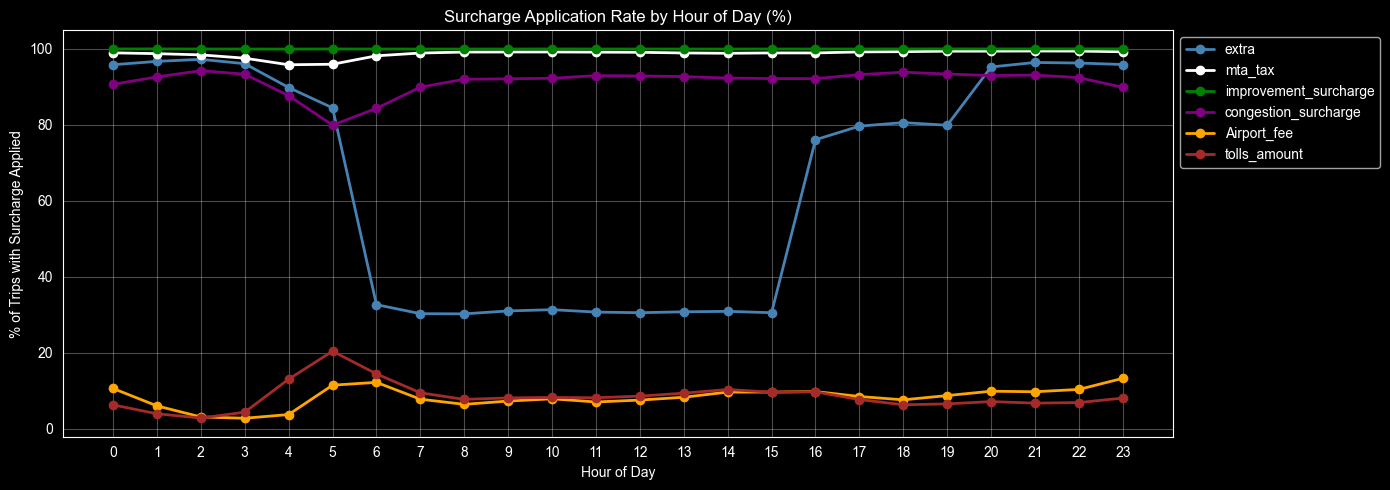

In [130]:
# How often is each surcharge applied?
surcharge_cols = ['extra', 'mta_tax', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee', 'tolls_amount']
for col in surcharge_cols:
    final_data_df[f'{col}_applied'] = (final_data_df[col]>0).astype(int)

surcharge_by_hour = (final_data_df
                     .groupby('tpep_pickup_datetime_hour')[[f'{col}_applied' for col in surcharge_cols]]
                     .mean()*100
                    ).reset_index()
#print(f"----Surcharges by Hour------\n{surcharge_by_hour}")
surcharge_by_hour

In [116]:
plt.figure(figsize=(14, 5))
colors = ['steelblue','white', 'green','purple', 'orange', 'brown']
for i, col in enumerate(surcharge_cols):
    plt.plot(surcharge_by_hour['tpep_pickup_datetime_hour'],surcharge_by_hour[f'{col}_applied'],marker='o',label=col,color=colors[i],linewidth=2)
plt.title('Surcharge Application Rate by Hour of Day (%)')
plt.xlabel('Hour of Day')
plt.ylabel('% of Trips with Surcharge Applied')
plt.xticks(range(24))
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(images_folder_path+'/surcharge_application_by_hour.png',dpi=150, bbox_inches='tight')
plt.show()

----Surcharges by PULocationID-----
     PULocationID                     zone  extra_applied  mta_tax_applied  \
0               1           Newark Airport       4.672897        12.616822   
1               2              Jamaica Bay       0.000000       100.000000   
2               3  Allerton/Pelham Gardens       0.000000        95.000000   
3               4            Alphabet City      80.655562        98.817840   
4               5            Arden Heights       0.000000       100.000000   
..            ...                      ...            ...              ...   
249           259       Woodlawn/Wakefield       6.382979        97.872340   
250           260                 Woodside      38.718663        92.479109   
251           261       World Trade Center      56.463364        98.251457   
252           262           Yorkville East      48.681035        99.724775   
253           263           Yorkville West      58.797212        99.698873   

     improvement_surcharge_

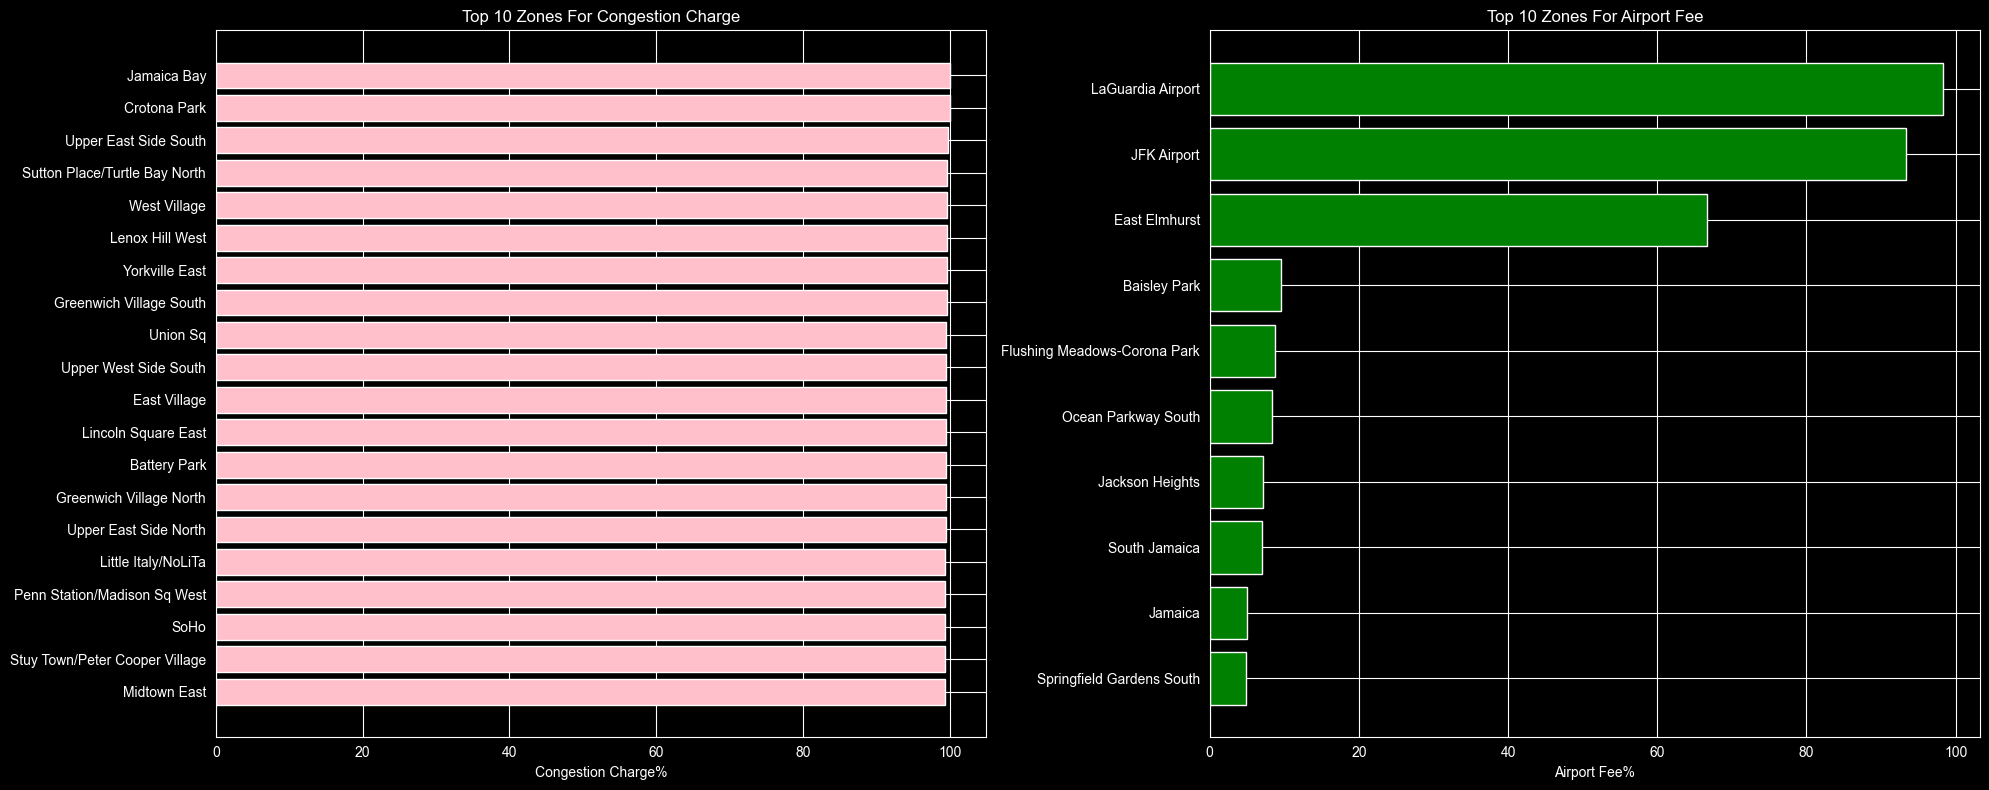


---Top 10 zones for congestion surcharges---
                              zone  congestion_surcharge_applied
1                      Jamaica Bay                    100.000000
56                    Crotona Park                    100.000000
228          Upper East Side South                     99.735337
220  Sutton Place/Turtle Bay North                     99.690543
239                   West Village                     99.688119
133                Lenox Hill West                     99.652714
252                 Yorkville East                     99.623153
106        Greenwich Village South                     99.610088
225                       Union Sq                     99.564654
230          Upper West Side South                     99.543198

---Top 10 zones for airport fees---
                             zone  Airport_fee_applied
130             LaGuardia Airport            98.338865
124                   JFK Airport            93.372928
67                  East Elmhurst    

In [117]:
surcharge_by_pu_location = (final_data_df
                     .groupby(['PULocationID','zone'])[[f'{col}_applied' for col in surcharge_cols]]
                     .mean()*100
                    ).reset_index()
print(f"----Surcharges by PULocationID-----\n{surcharge_by_pu_location}")

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(20,8))

top10_zones_congestion_surcharge = (surcharge_by_pu_location.sort_values(by='congestion_surcharge_applied',ascending=False).head(20))[['zone','congestion_surcharge_applied']]
ax[0].barh(top10_zones_congestion_surcharge['zone'],top10_zones_congestion_surcharge['congestion_surcharge_applied'],color='pink')
ax[0].set_title('Top 10 Zones For Congestion Charge')
ax[0].set_xlabel('Congestion Charge%')
ax[0].invert_yaxis()

top10_zones_airport_fee = (surcharge_by_pu_location.sort_values(by='Airport_fee_applied',ascending=False).head(10))[['zone','Airport_fee_applied']]
ax[1].barh(top10_zones_airport_fee['zone'],top10_zones_airport_fee['Airport_fee_applied'],color='green')
ax[1].set_title('Top 10 Zones For Airport Fee')
ax[1].invert_yaxis()
ax[1].set_xlabel('Airport Fee%')
plt.tight_layout()
plt.show()

print(f"\n---Top 10 zones for congestion surcharges---\n{top10_zones_congestion_surcharge.head(10)}")
print(f"\n---Top 10 zones for airport fees---\n{top10_zones_airport_fee}")

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

##Concluding Story

The analysis of 2023 NYC Yellow Taxi dataset reveals that taxi demand and revenue are heavily influenced by three key parameters:-

**Location** is the most important factor; JFK airport leads hourly pickups while upper east side dominates the drop-offs. The areas like Upper Wast Side South, Midtown Center, Midtown East, Times Sq, etc (which are part of the Manhattan area) also appear frequently in both top pickup and drop-off lists, confirming that the main business lies in those areas. Airports show asymmetric traffic with high pickups but not present in the top drop-off zones.

**Time of day** drives the fare efficiency with daytime revenue share being approximately 88%. The evening rush  (between 4-6 PM) generates the highest fare per mile (with $9.54/mile at 6PM) while early morning (5-6AM) is least efficient (With $6.50/mile). Late night hours see the highest sharing passengers maybe because groups return from late night events.

**Day of week** creates a clear split between Weekday vs Weekend revenue; with Wednesday  and Thursday  yielding the highest fare per mile ($8.79 and $8.75 approx.), while Sunday being the least profitable day. However, it can be observed that Saturday and Sunday record the highest average passenger sharing suggesting groups of travellers availing cabs for leisure purposes.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

### Key Business Insights

1. **Evening rush (4-6PM)** generates the highest fare per mile. Vendors should route cabs toward **Manhattan area districts** by **4PM** to capture this demand.

2. **JFK Airport** is the highest pickup zone with around **4100 avg hourly pickups** followed by **LaGuardia Airport** at **2600 avg hourly pickups**. A dedicated fleet should be assigned to the airport pickups throughout the day as flights arrive at all hours. Again airport trips will carry additional **"Airport Fee"** on top of the base fare.
3. **Fare per mile drops** between **4-6AM** to **$6.45/mile at 5AM**. These hours **can be utilised to allocate cabs** for airport pickups rather than the short city trips. At these hours several pickups can be made for the airport since traffic is also lesser.

4. Even though **nighttime revenue share** is only around **12.1%** approximately, the **per trip revenue** is about $29.5/trip in comparison to the **daytime fare** of $$28.78/trip. Hence a significant fleet of cabs should be allocated to **entertainment/event zones** where **avg sharing** is also high at around **1.42-1.46**.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

In [ ]:
zone_pickups_by_hour = (final_data_df
                .groupby(['PULocationID', 'tpep_pickup_datetime_hour'])
                .size()
                .reset_index(name='trip_count'))
zone_pickups_by_hour = zone_pickups_by_hour.merge(zones[['zone','LocationID']], how='left', left_on='PULocationID', right_on='LocationID')
mornings = (zone_pickups_by_hour[zone_pickups_by_hour['tpep_pickup_datetime_hour'].isin([6,7,8,9,10])]
            .groupby('zone')['trip_count'].sum()).sort_values(ascending=False).head(10)
afternoons = (zone_pickups_by_hour[zone_pickups_by_hour['tpep_pickup_datetime_hour'].isin([12,13,14,15])]
            .groupby('zone')['trip_count'].sum()).sort_values(ascending=False).head(10)
evenings = (zone_pickups_by_hour[zone_pickups_by_hour['tpep_pickup_datetime_hour'].isin([16,17,18,19])]
            .groupby('zone')['trip_count'].sum()).sort_values(ascending=False).head(10)
nights = (zone_pickups_by_hour[zone_pickups_by_hour['tpep_pickup_datetime_hour'].isin([22,23,0,1,2,3])]
            .groupby('zone')['trip_count'].sum()).sort_values(ascending=False).head(10)

print(f"Top 5 Morning Pickup Zones (6-10am):\n{mornings}")
print(f"\nTop 5 Afternoon Pickup Zones (12-3pm):\n{afternoons}")
print(f"\nTop 5 Evening Pickup Zones (4-7pm):\n{evenings}")
print(f"\nTop 5 Night Pickup Zones (10pm-3am):\n{nights}")

**Morning (6-10AM)**
JFK Airport routes are already active at fourth position. Position more cabs in Upper East Side and Penn Station zones by 6AM to capture the morning demand peak.

**Afternoon (12-3PM)**
Midtown Center increases to 22k (even though its absent from the morning trips). Both airports pickup increases in afternoon suggesting that the pickup activity is consistent during the afternoon hours as well. It is suggested to maintain Upper East Side presence while increasing the Midtown Center and airport zone coverage from midday onwards.

**Evening (4-7PM)**
Most significant shift of the day occurs for Midtown center as it moves from #3 in afternoon to #1 in evening (~27K trips). This also coincides with our analysis of highest fare-per-mile by hour ($9.42 at 6PM). JFK airport pickups also rises to #2. It is recommended to move the cab fleet towards Midtown Center during the 4-7PM window since high number of trips and high fare-per-mile makes this one of the areas which can generate more profits.

**Night (10PM-3AM)**
Deploy a dedicated fleet of cabs to areas such as East Village, West Village, Clinton East and Times Sq during the night while maintaining a large fleet at the JFK airport. It could be possible that East Village, West Village, Clinton East and Times Sq are part of the entertainment areas and hence attract there is a significant crowd in this area exclusively at night.


**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

### Distance-tiered pricing ###
-> Short trips (0-2 miles):<br>
    highest fare/mile of around $8.53/mile.<br>
    Keep the fares lower so that customers can avail cabs for shorter distances.<br>

-> Medium trips (2-5 miles):<br>
    moderate fare/mile (~$7.87/mile)
    current pricing is competitive

-> Long trips (5+ miles):<br>
    these are most profitable trips overall
    incentivize drivers to take long trips

### Time based pricing ###
-> Late night surcharges can be considered to be increased.
    tipping is higher during the late hours (~31% at 3AM)
-> Rush hours (7-9AM, 4-7PM) are the highest demand periods mostly for corporate workers
    ensure surge pricing mechanisms are active during this period and can be increased/decreased depending on the traffic.
